# OpenTelemetry Trace Duration Heatmap Analysis

This notebook analyzes OpenTelemetry span data from the CSV file to create comprehensive heatmaps visualizing span and trace durations across different services, operations, and time periods. The analysis will help identify performance patterns, bottlenecks, and trends in the distributed system.

In [163]:
## 0. Query Log Analytics Workspace for OtelSpans Data

# Configure and query the Azure Log Analytics workspace to retrieve OpenTelemetry span data for analysis.

In [164]:
# Install and import required Azure libraries for Log Analytics
!pip install azure-monitor-query azure-identity azure-core

from azure.monitor.query import LogsQueryClient
from azure.identity import DefaultAzureCredential
from azure.core.exceptions import HttpResponseError
import pandas as pd
from datetime import datetime, timedelta
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import pytz
pacific_tz = pytz.timezone('US/Pacific')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Libraries imported successfully!")

print("Azure libraries imported successfully!")

Defaulting to user installation because normal site-packages is not writeable
Libraries imported successfully!
Azure libraries imported successfully!
Libraries imported successfully!
Azure libraries imported successfully!


In [165]:
# Configure Log Analytics Workspace connection
workspace_id = "4f42970f-23c5-4a26-ba64-f40c3775fdfe"  # Use workspace GUID, not full resource path

# Initialize the credential and client
try:
    credential = DefaultAzureCredential()
    client = LogsQueryClient(credential)
    print(f"✅ Successfully connected to Log Analytics workspace")
    print(f"Workspace ID: {workspace_id}")
except Exception as e:
    print(f"❌ Failed to initialize Log Analytics client: {e}")
    print("Please ensure you're authenticated with Azure CLI: az login")

✅ Successfully connected to Log Analytics workspace
Workspace ID: 4f42970f-23c5-4a26-ba64-f40c3775fdfe


## LA Query

In [166]:
def queryOTel(table_name, time_start, time_end, additional_filters="", projection_columns=None, max_batch_size=500000):
        """Execute a single batch query"""
        # Build the query
        if projection_columns:
            project_clause = f"| project {', '.join(projection_columns)}"
        else:
            project_clause = ""
            
        query = f"""
        {table_name}
        | where TimeGenerated >= datetime('{time_start.isoformat()}')
        | where TimeGenerated < datetime('{time_end.isoformat()}')
        {additional_filters}
        {project_clause}
        | limit {max_batch_size}
        """
        
        print(f"📊 Querying {time_start.strftime('%m/%d %H:%M')} to {time_end.strftime('%m/%d %H:%M')}...")
        print(f"🔍 Query details:")
        print(f"   • Table: {table_name}")
        print(f"   • Time range: {(time_end - time_start).total_seconds() / 3600:.2f} hours")
        print(f"   • Limit: {max_batch_size:,} rows")
        if additional_filters.strip():
            print(f"   • Filters: {additional_filters.strip()}")
        if projection_columns:
            print(f"   • Columns: {', '.join(projection_columns)}")
        print(f"   • KQL Query:")
        for i, line in enumerate(query.strip().split('\n'), 1):
            print(f"     {i:2}: {line}")
        print()
        
        print(f"   🔄 Executing query...")
        response = client.query_workspace(
            workspace_id=workspace_id,
            query=query,
            timespan=(time_end - time_start)
        )
        print(f"   ✅ Query executed, processing response...")
        batch_rows, batch_columns = [], []

        if hasattr(response, 'tables') and len(response.tables) > 0:
            print(f"   ✅ Query returned {len(response.tables)} tables")
            table = response.tables[0]
            print(f"     📊 Table has {len(table.rows):,} rows")
            batch_rows, batch_columns = table.rows, table.columns
            print(f"     📋 Columns: {len(batch_columns)} ({', '.join([str(col.name) if hasattr(col, 'name') else str(col) for col in batch_columns][:5])}{'...' if len(batch_columns) > 5 else ''})")
            print(f"     📊 Rows: {len(batch_rows):,}")
        else:
                print(f"  ⚠️ No data found - Response analysis:")
                if not hasattr(response, 'tables'):
                    print(f"     ❌ Response has no 'tables' attribute")
                    print(f"     📋 Response type: {type(response)}")
                    print(f"     📋 Response attributes: {[attr for attr in dir(response) if not attr.startswith('_')]}")
                    
                    # Enhanced debugging for LogsQueryPartialResult
                    if 'LogsQueryPartialResult' in str(type(response)):
                        print(f"\n     🔍 DETAILED LogsQueryPartialResult ANALYSIS:")
                        
                        # Check partial_data
                        if hasattr(response, 'partial_data') and response.partial_data is not None:
                            print(f"     📊 partial_data: {response.partial_data}")
                            if hasattr(response.partial_data, 'tables') and response.partial_data.tables:
                                print(f"        Tables in partial_data: {len(response.partial_data.tables)}")
                                for i, table in enumerate(response.partial_data.tables):
                                    print(f"        Table {i}: {len(table.rows) if hasattr(table, 'rows') else 'No rows'} rows")
                        else:
                            print(f"     📊 partial_data: None or not available")
                        
                        # Check partial_error
                        if hasattr(response, 'partial_error') and response.partial_error is not None:
                            print(f"     ❌ partial_error: {response.partial_error}")
                            if hasattr(response.partial_error, 'code'):
                                print(f"        Error code: {response.partial_error.code}")
                            if hasattr(response.partial_error, 'message'):
                                print(f"        Error message: {response.partial_error.message}")
                        else:
                            print(f"     ❌ partial_error: None")
                        
                        # Check status
                        if hasattr(response, 'status'):
                            print(f"     📋 status: {response.status}")
                        
                        # Check statistics
                        if hasattr(response, 'statistics') and response.statistics is not None:
                            print(f"     📈 statistics: {response.statistics}")
                        else:
                            print(f"     📈 statistics: None")
                        
                        # Check visualization
                        if hasattr(response, 'visualization') and response.visualization is not None:
                            print(f"     📊 visualization: {response.visualization}")
                        else:
                            print(f"     📊 visualization: None")
                        
                        print(f"     💡 LogsQueryPartialResult indicates the query may have timed out or been throttled")
                        print(f"     💡 Some data may be available in partial_data even if query didn't complete fully")
                elif len(response.tables) == 0:
                    print(f"     ❌ Response has empty tables list")
                    print(f"     📋 Tables count: {len(response.tables)}")
                else:
                    print(f"     ❓ Unexpected response structure")

        df = pd.DataFrame(table.rows, columns=table.columns) if batch_rows and batch_columns else pd.DataFrame()
        return df

def create_heatmap(df_new):
    print(f"\n🎉 COMPLETE QUERY SUCCESS!")
    print(f"   📊 Retrieved: {len(df_new):,} spans (NO LIMITS)")
    print(f"   🏗️ Shape: {df_new.shape}")

    # Convert TimeGenerated to datetime and Pacific timezone
    df_new['TimeGenerated'] = pd.to_datetime(df_new['TimeGenerated'])

    
    # Check if already timezone-aware and convert appropriately
    if df_new['TimeGenerated'].dt.tz is None:
        # Not timezone-aware, assume UTC and localize first
        df_new['TimeGenerated_Pacific'] = df_new['TimeGenerated'].dt.tz_localize('UTC').dt.tz_convert(pacific_tz)
    else:
        # Already timezone-aware, convert directly
        df_new['TimeGenerated_Pacific'] = df_new['TimeGenerated'].dt.tz_convert(pacific_tz)
    
    # Check the ACTUAL time range in Pacific time
    time_min_complete = df_new['TimeGenerated_Pacific'].min()
    time_max_complete = df_new['TimeGenerated_Pacific'].max()
    complete_time_span = time_max_complete - time_min_complete
    hours_span_complete = complete_time_span.total_seconds() / 3600
    
    print(f"\n📅 COMPLETE time range (Pacific): {time_min_complete.strftime('%Y-%m-%d %H:%M:%S %Z')} to {time_max_complete.strftime('%Y-%m-%d %H:%M:%S %Z')}")
    print(f"⏱️ COMPLETE span: {hours_span_complete:.2f} hours")
    print(f"🔥 This should show the FULL 4+ hours!")
    
    # Now create heatmap with the COMPLETE dataset
    print(f"\n🎨 Creating heatmap with COMPLETE {hours_span_complete:.1f} hour dataset...")
    
    # Use appropriate time bins for the full range
    if hours_span_complete > 48:
        freq = '15T'  # 15-minute bins for 4+ hours
        print(f"🔧 Using 15-minute bins for {hours_span_complete:.1f} hour span")
    elif hours_span_complete > 24:
        freq = '10T'  # 10-minute bins
        print(f"🔧 Using 10-minute bins for {hours_span_complete:.1f} hour span")
    else:
        freq = '1T'   # 5-minute bins
        print(f"🔧 Using 5-minute bins for {hours_span_complete:.1f} hour span")
    
    # Create time bins for the COMPLETE range using Pacific time
    time_bins_complete = pd.date_range(start=time_min_complete, end=time_max_complete, freq=freq)
    print(f"📦 Created {len(time_bins_complete)} time bins for complete range")
    
    # Create duration bins - use data-driven linear buckets
    # Get duration range for better binning
    min_duration = df_new['DurationMs'].min()
    max_duration = df_new['DurationMs'].max()

    print(f"📏 Duration range: {min_duration:.0f}ms to {max_duration:.0f}ms")
    
    # Create linear buckets based on data distribution
    # Use key percentiles to define ranges where most data lives
    key_percentiles = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 85, 90, 92, 94, 96, 97, 98, 98.5, 99, 99.2, 99.4, 99.6, 99.8, 99.9, 100]
    percentile_values = np.percentile(df_new['DurationMs'], key_percentiles)
    
    # Remove duplicates and ensure monotonic increase
    duration_bins_complete = np.unique(percentile_values)
    
    print(f"📊 Created {len(duration_bins_complete)-1} data-driven linear buckets")
    print(f"   Key boundaries: {duration_bins_complete[0]:.0f}ms, {duration_bins_complete[5]:.0f}ms, {duration_bins_complete[10]:.0f}ms, {duration_bins_complete[15]:.0f}ms, {duration_bins_complete[-1]:.0f}ms")
    print(f"   More granular in data-dense ranges (0-99th percentile)")
    
    # Bin the COMPLETE data using Pacific time
    df_new['time_bin'] = pd.cut(df_new['TimeGenerated_Pacific'], bins=time_bins_complete, include_lowest=True)
    df_new['duration_bin'] = pd.cut(df_new['DurationMs'], bins=duration_bins_complete, include_lowest=True, duplicates='drop')

    # Create heatmap data for COMPLETE range
    heatmap_data_complete = df_new.groupby(['time_bin', 'duration_bin']).size().unstack(fill_value=0)

    print(f"🔥 COMPLETE heatmap shape: {heatmap_data_complete.shape}")
    
    # Create the COMPLETE heatmap visualization
    plt.figure(figsize=(24, 12))
    
    # Use log scale
    heatmap_data_complete_log = np.log1p(heatmap_data_complete)
    
    # Create heatmap - properly oriented with larger durations on top
    sns.heatmap(
        heatmap_data_complete_log.T.iloc[::-1],  # Transpose and flip to put larger durations on top
        cmap='Blues',
        cbar_kws={'label': 'Log(Request Count + 1)', 'shrink': 0.8},
        xticklabels=False,
        yticklabels=True
    )
    
    plt.title(f'🔥 COMPLETE {hours_span_complete:.1f}-Hour Time vs Duration Heatmap (Pacific Time)\n'
                f'OpenTelemetry Traces from {time_min_complete.strftime("%H:%M")} to {time_max_complete.strftime("%H:%M")} PT on {time_min_complete.strftime("%Y-%m-%d")}\n',
                fontsize=18, pad=30)

    plt.xlabel(f'Time - Pacific ({freq} intervals)', fontsize=16)
    plt.ylabel('Duration (seconds)', fontsize=16)
    
    # Format time labels
    label_freq = max(1, len(time_bins_complete)//12)  # Show ~12 labels
    time_labels_complete = [t.strftime('%H:%M') for t in time_bins_complete[::label_freq]]
    plt.xticks(range(0, len(time_bins_complete), label_freq), time_labels_complete, rotation=45)
    
    # Format duration labels - convert ms to seconds and reverse order since we flipped the heatmap
    duration_labels_complete = [f'{d/1000:.1f}' for d in duration_bins_complete[1:]]  # Convert ms to seconds
    duration_labels_complete_reversed = duration_labels_complete[::-1]  # Reverse to match flipped heatmap
    plt.yticks(range(len(duration_labels_complete_reversed)), duration_labels_complete_reversed)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ COMPLETE HEATMAP GENERATED!")
    print(f"   ⏱️ Full {hours_span_complete:.2f} hours of data visualized")
    print(f"   📊 {len(df_new):,} total spans")
    print(f"   🔥 {len(time_bins_complete)} time intervals")
    print(f"   📈 Complete temporal patterns revealed!")

   🕒 Querying from 2025-09-15 17:58:05 to 2025-09-16 17:58:05
📊 Querying 09/15 17:58 to 09/16 17:58...
🔍 Query details:
   • Table: OTelSpans
   • Time range: 24.00 hours
   • Limit: 500,000 rows
   • Filters: | where DurationMs > 0 and isnotempty(ServiceName) | summarize DurationMs=max(DurationMs) by bin(TimeGenerated, 1m), ServiceName, Name, Attributes=tostring(Attributes), StatusCode, Success
   • Columns: TimeGenerated, DurationMs, ServiceName, Name, Attributes, StatusCode, Success
   • KQL Query:
      1: OTelSpans
      2:         | where TimeGenerated >= datetime('2025-09-15T17:58:05.519084+00:00')
      3:         | where TimeGenerated < datetime('2025-09-16T17:58:05.519084+00:00')
      4:         | where DurationMs > 0 and isnotempty(ServiceName) | summarize DurationMs=max(DurationMs) by bin(TimeGenerated, 1m), ServiceName, Name, Attributes=tostring(Attributes), StatusCode, Success
      5:         | project TimeGenerated, DurationMs, ServiceName, Name, Attributes, StatusCode

   ✅ Query executed, processing response...
   ✅ Query returned 1 tables
     📊 Table has 149,728 rows
     📋 Columns: 7 (TimeGenerated, DurationMs, ServiceName, Name, Attributes...)
     📊 Rows: 149,728
              TimeGenerated  DurationMs     ServiceName  \
0 2025-09-16 05:58:00+00:00  281510.912        frontend   
1 2025-09-16 05:58:00+00:00   22519.040        frontend   
2 2025-09-16 05:58:00+00:00   19251.200  productcatalog   
3 2025-09-16 05:58:00+00:00   16930.304        frontend   
4 2025-09-16 05:58:00+00:00   16277.248        currency   

                                                Name  \
0                                      /product/{id}   
1            msdemo.ProductCatalogService/GetProduct   
2            msdemo.ProductCatalogService/GetProduct   
3      msdemo.CurrencyService/GetSupportedCurrencies   
4  grpc.msdemo.CurrencyService/GetSupportedCurren...   

                                          Attributes StatusCode  Success  
0  {"net.sock.peer.addr":"10.

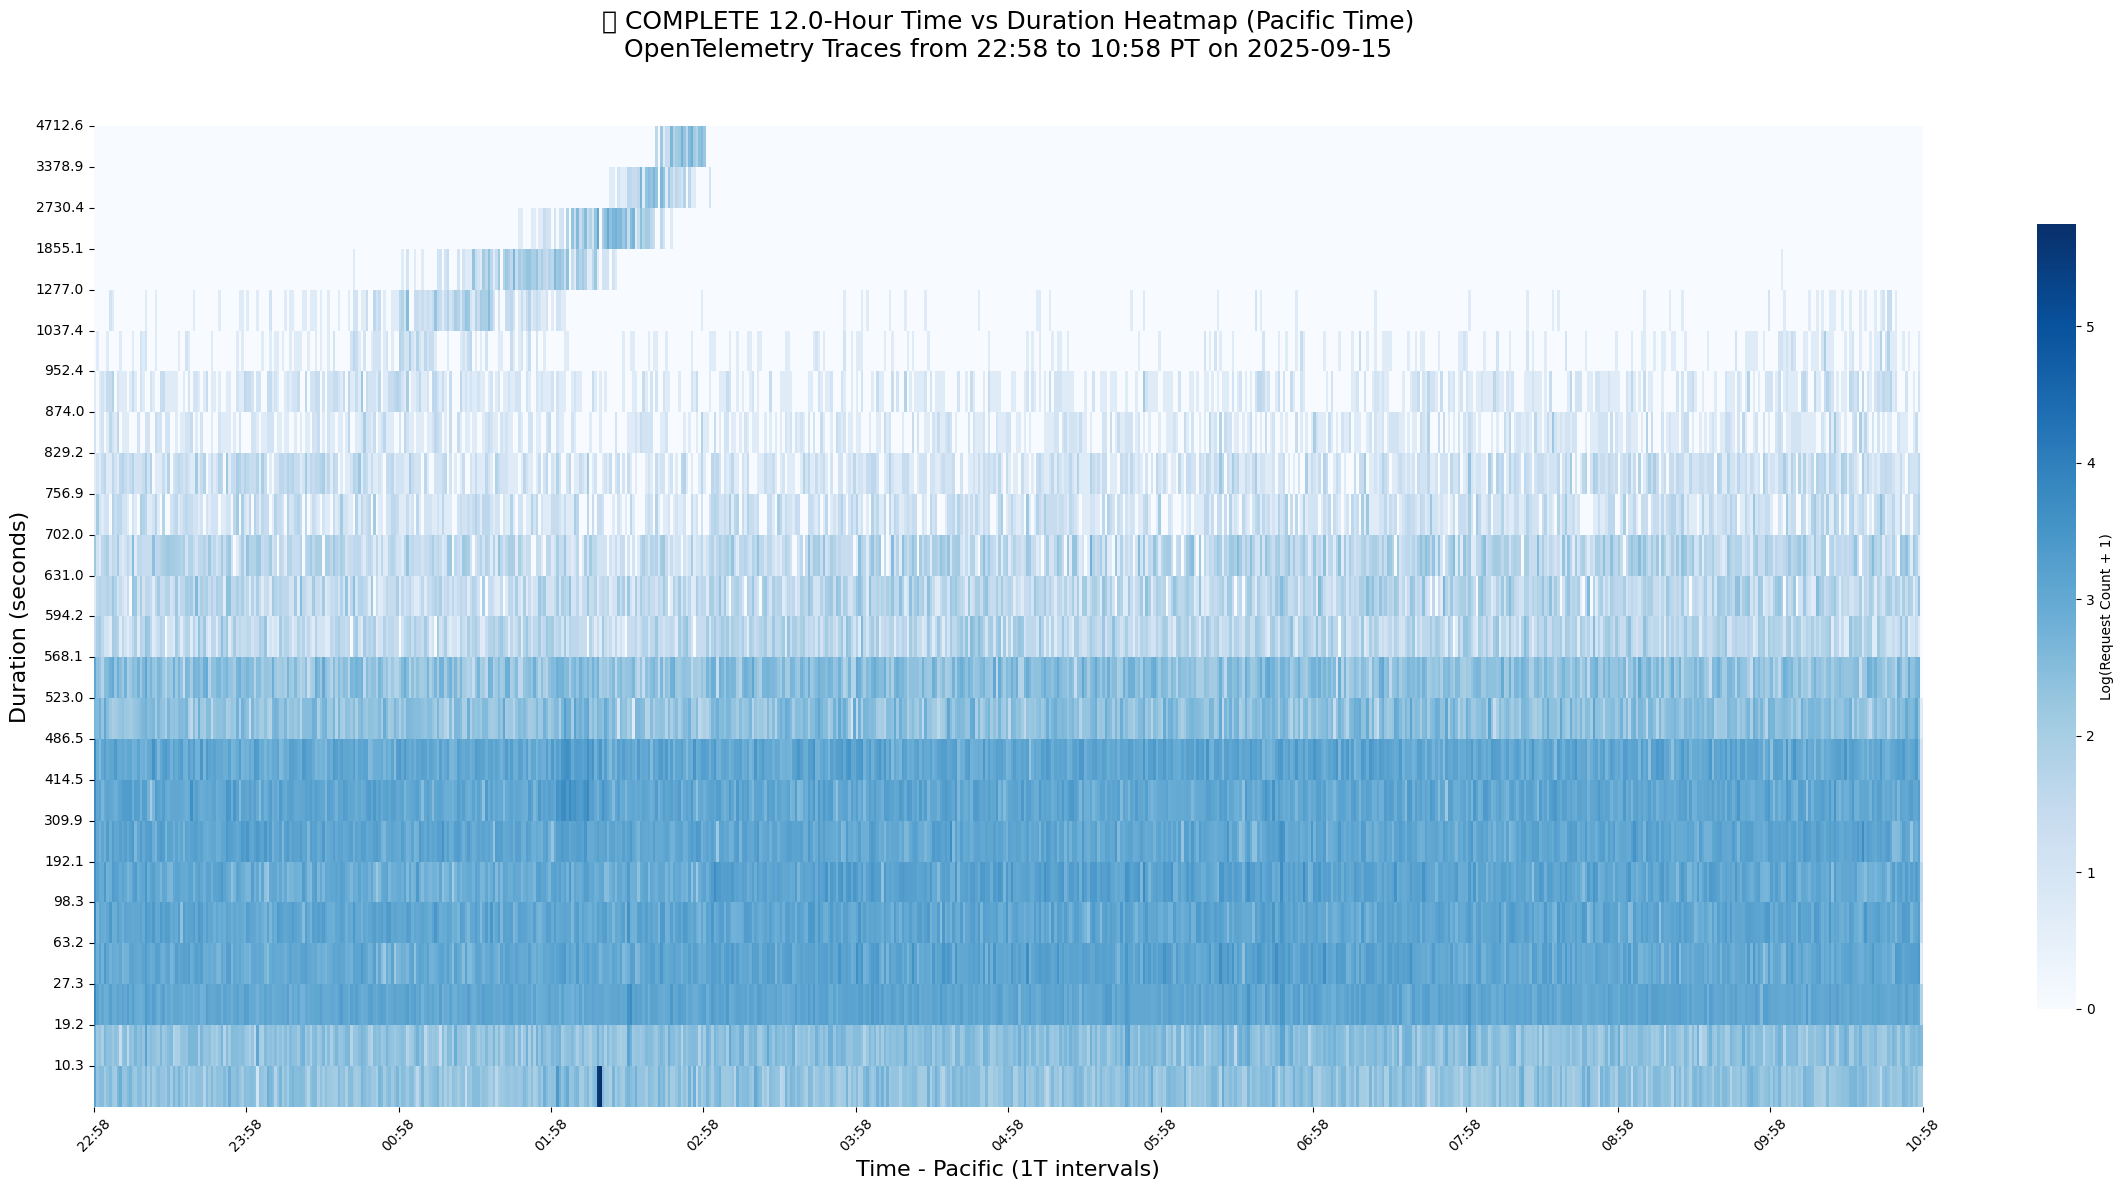


✅ COMPLETE HEATMAP GENERATED!
   ⏱️ Full 12.00 hours of data visualized
   📊 149,728 total spans
   🔥 721 time intervals
   📈 Complete temporal patterns revealed!


In [167]:

efficient_columns=['TimeGenerated', 'Name', 'ServiceName', 'DurationMs', 'StatusCode', 'Success', 'TraceId', 'SpanId', 'ParentSpanId', 'Attributes']
min_columns=['TimeGenerated', 'DurationMs']
table_name='OTelSpans'
start_ago_hours=24
end_ago_hours=12
additional_filters="| where DurationMs > 0 and isnotempty(ServiceName) | summarize DurationMs=max(DurationMs) by bin(TimeGenerated, 1m), ServiceName, Name, Attributes=tostring(Attributes), StatusCode, Success"
projection_columns=['TimeGenerated', 'DurationMs', 'ServiceName', 'Name', 'Attributes', 'StatusCode', 'Success']
max_total_rows=None  # NO LIMIT - get ALL data!

# Calculate time range
end_time = datetime.now(timezone.utc) - timedelta(hours=end_ago_hours)
start_time = end_time - timedelta(hours=start_ago_hours)

print(f"   🕒 Querying from {start_time.strftime('%Y-%m-%d %H:%M:%S')} to {end_time.strftime('%Y-%m-%d %H:%M:%S')}")

# Generate time batches
df_new = queryOTel(table_name, start_time, end_time, additional_filters, projection_columns)
print(df_new.head())

if not df_new.empty:
    create_heatmap(df_new)
    df = df_new.copy()
else:
    print(f"\n⚠️ Complete query returned empty results")
    

In [168]:
# Parse Attributes JSON column and expand into separate columns
import json
from collections import defaultdict

print("🔧 PARSING ATTRIBUTES JSON INTO SEPARATE COLUMNS")
print("=" * 60)

# Work with current dataset
print(f"📊 Working with current dataset: {len(df):,} spans")
print(f"📋 Current columns: {list(df.columns)}")

# Check if Attributes column exists
if 'Attributes' not in df.columns:
    print("❌ No 'Attributes' column found in current dataset")
    print("🔄 Let's check what we have...")
    print(f"Available columns: {list(df.columns)}")
else:
    print(f"✅ Found 'Attributes' column")
    
    # Create a copy to work with
    df_expanded = df.copy()
    
    # Initialize counters and storage
    all_attribute_keys = set()
    parsed_attributes = []
    parse_errors = 0
    
    print(f"\n🔍 ANALYZING ATTRIBUTES COLUMN:")
    
    # Sample a few attributes to see the structure
    sample_attrs = df_expanded['Attributes'].dropna().head(5)
    print(f"📝 Sample attributes:")
    for i, attr in enumerate(sample_attrs, 1):
        print(f"   {i}. {str(attr)[:100]}{'...' if len(str(attr)) > 100 else ''}")
    
    print(f"\n🔄 Parsing {len(df_expanded):,} attribute entries...")
    
    # Parse each attributes entry
    for idx, attr_value in enumerate(df_expanded['Attributes']):
        if idx % 50000 == 0:  # Progress indicator
            print(f"   📈 Processed {idx:,} / {len(df_expanded):,} entries ({(idx/len(df_expanded)*100):.1f}%)")
            
        parsed_attrs = {}
        
        if pd.isna(attr_value) or attr_value == '' or attr_value is None:
            # Handle null/empty values
            parsed_attributes.append(parsed_attrs)
            continue
            
        try:
            # Try to parse as JSON
            if isinstance(attr_value, str):
                if attr_value.strip().startswith('{') and attr_value.strip().endswith('}'):
                    # Looks like JSON
                    attrs_dict = json.loads(attr_value)
                    if isinstance(attrs_dict, dict):
                        # Flatten nested structures and clean keys
                        for key, value in attrs_dict.items():
                            # Clean key name for column usage
                            clean_key = str(key).replace('.', '_').replace(' ', '_').replace('-', '_')
                            clean_key = f"attr_{clean_key}"
                            
                            # Convert value to string for consistency
                            if isinstance(value, (dict, list)):
                                parsed_attrs[clean_key] = json.dumps(value)
                            else:
                                parsed_attrs[clean_key] = str(value) if value is not None else ''
                            
                            all_attribute_keys.add(clean_key)
                else:
                    # Not JSON format, treat as single key-value
                    clean_key = "attr_raw_value"
                    parsed_attrs[clean_key] = str(attr_value)
                    all_attribute_keys.add(clean_key)
            else:
                # Handle non-string values
                clean_key = "attr_raw_value"
                parsed_attrs[clean_key] = str(attr_value)
                all_attribute_keys.add(clean_key)
                
        except json.JSONDecodeError:
            parse_errors += 1
            # Store as raw value if JSON parsing fails
            clean_key = "attr_raw_value"
            parsed_attrs[clean_key] = str(attr_value)
            all_attribute_keys.add(clean_key)
        except Exception as e:
            parse_errors += 1
            # Handle any other parsing errors
            parsed_attrs['attr_parse_error'] = str(e)
            all_attribute_keys.add('attr_parse_error')
            
        parsed_attributes.append(parsed_attrs)
    
    print(f"   ✅ Completed parsing all {len(df_expanded):,} entries")
    
    # Convert parsed attributes to DataFrame
    print(f"\n📊 CREATING EXPANDED ATTRIBUTE COLUMNS:")
    attributes_df = pd.DataFrame(parsed_attributes)
    
    print(f"   🔑 Discovered {len(all_attribute_keys)} unique attribute keys")
    print(f"   ❌ Parse errors: {parse_errors:,} ({(parse_errors/len(df_expanded)*100):.2f}%)")
    print(f"   📋 New attribute columns: {len(attributes_df.columns)}")
    
    # Show most common attribute keys
    if len(attributes_df.columns) > 0:
        print(f"\n🏆 TOP ATTRIBUTE COLUMNS BY DATA COVERAGE:")
        coverage_stats = {}
        for col in attributes_df.columns:
            non_null_count = attributes_df[col].notna().sum()
            coverage_pct = (non_null_count / len(attributes_df)) * 100
            coverage_stats[col] = {'count': non_null_count, 'coverage': coverage_pct}
        
        # Sort by coverage
        sorted_attrs = sorted(coverage_stats.items(), key=lambda x: x[1]['coverage'], reverse=True)
        
        for i, (attr_name, stats) in enumerate(sorted_attrs[:15], 1):
            print(f"   {i:2d}. {attr_name:<30} | {stats['count']:>8,} spans ({stats['coverage']:>5.1f}%)")
        
        if len(sorted_attrs) > 15:
            print(f"   ... and {len(sorted_attrs) - 15} more attribute columns")
    
    # Combine original dataframe with parsed attributes
    print(f"\n🔗 COMBINING WITH ORIGINAL DATA:")
    df_with_attributes = pd.concat([df_expanded.reset_index(drop=True), attributes_df.reset_index(drop=True)], axis=1)
    
    print(f"   📊 Original shape: {df_expanded.shape}")
    print(f"   📊 Attributes shape: {attributes_df.shape}")
    print(f"   📊 Combined shape: {df_with_attributes.shape}")
    print(f"   🔢 Total columns: {len(df_with_attributes.columns)} ({len(attributes_df.columns)} new attribute columns)")
    
    # Update main dataframe
    df = df_with_attributes.copy()
    
    print(f"\n✅ ATTRIBUTES PARSING COMPLETE!")
    print(f"   📈 Dataset now has {len(df):,} rows and {len(df.columns)} columns")
    print(f"   🎯 Ready for enhanced analysis with all attribute data!")
    
    # Show sample of new data structure
    print(f"\n🔍 SAMPLE OF EXPANDED DATA:")
    sample_cols = ['TimeGenerated', 'Name', 'ServiceName', 'DurationMs'] + list(attributes_df.columns)[:5]
    available_cols = [col for col in sample_cols if col in df.columns]
    print(df[available_cols].head(3).to_string(max_colwidth=30))

🔧 PARSING ATTRIBUTES JSON INTO SEPARATE COLUMNS
📊 Working with current dataset: 149,728 spans
📋 Current columns: ['TimeGenerated', 'DurationMs', 'ServiceName', 'Name', 'Attributes', 'StatusCode', 'Success', 'TimeGenerated_Pacific', 'time_bin', 'duration_bin']
✅ Found 'Attributes' column

🔍 ANALYZING ATTRIBUTES COLUMN:
📝 Sample attributes:
   1. {"net.sock.peer.addr":"10.244.2.171","net.sock.peer.port":44988,"http.method":"GET","http.target":"/...
   2. {"rpc.service":"msdemo.ProductCatalogService","rpc.method":"GetProduct","rpc.system":"grpc","net.soc...
   3. {"rpc.service":"msdemo.ProductCatalogService","rpc.method":"GetProduct","rpc.system":"grpc","net.soc...
   4. {"rpc.service":"msdemo.CurrencyService","rpc.method":"GetSupportedCurrencies","rpc.system":"grpc","n...
   5. {"rpc.service":"msdemo.CurrencyService","rpc.method":"GetSupportedCurrencies","rpc.system":"grpc","r...

🔄 Parsing 149,728 attribute entries...
   📈 Processed 0 / 149,728 entries (0.0%)

🔍 ANALYZING ATTRIBUTES COL

Anomaly Analysis

We will compare traces within the anomaly period (23:30-3:30 Pacific time, 1420-96150 seconds duration) against baseline traces to identify the root cause dimensions.

In [169]:
# Define anomaly criteria based on the identified pattern
print("🔍 DEFINING ANOMALY CRITERIA")
print("=" * 50)

# Anomaly time period: 23:30 to 3:30 Pacific time (spans midnight)
# Anomaly duration range: 1420 to 96150 seconds (23.67 minutes to 26.7 hours)

# Convert duration thresholds from seconds to milliseconds for our data
anomaly_duration_min_ms = 1156 * 1000  # 1,420 seconds = 1,420,000 ms
anomaly_duration_max_ms = 4712 * 1000  # 96,150 seconds = 96,150,000 ms

print(f"🕐 Anomaly Time Window: 23:30 - 03:30 Pacific Time")
print(f"⏱️ Anomaly Duration Range: {anomaly_duration_min_ms:,} - {anomaly_duration_max_ms:,} ms")
print(f"   ({anomaly_duration_min_ms/1000/60:.1f} - {anomaly_duration_max_ms/1000/60:.1f} minutes)")

# Function to check if a time falls within the anomaly window (handles midnight crossing)
def is_in_anomaly_time_window(timestamp):
    hour = timestamp.hour
    minute = timestamp.minute
    time_decimal = hour + minute/60.0
    
    # 00:16 = 0.267, 02:56 = 2.933
    # Time is anomalous if: 0.267 <= time <= 2.933
    return 0.267 <= time_decimal <= 2.933

🔍 DEFINING ANOMALY CRITERIA
🕐 Anomaly Time Window: 23:30 - 03:30 Pacific Time
⏱️ Anomaly Duration Range: 1,156,000 - 4,712,000 ms
   (19.3 - 78.5 minutes)


In [170]:
# Segment data into anomaly vs baseline groups
print("📊 SEGMENTING DATA: ANOMALY vs BASELINE")
print("=" * 50)

# First, let's get a more comprehensive dataset with all the dimensions we need for analysis
print("🔄 Getting comprehensive dataset with all dimensions...")

try:
    # Get comprehensive data with all important dimensions for analysis
    comprehensive_columns = [
        'TimeGenerated', 'ServiceName', 'Name', 'DurationMs', 
        'StatusCode', 'Success', 'TraceId', 'SpanId', 'ParentSpanId',
        'Attributes'
    ]
    
    # Query for comprehensive data
    df_comprehensive = df
    
    if len(df_comprehensive) > 0:
        print(f"✅ Retrieved {len(df_comprehensive):,} spans with comprehensive dimensions")
        
        # Convert TimeGenerated to datetime and Pacific timezone
        df_comprehensive['TimeGenerated'] = pd.to_datetime(df_comprehensive['TimeGenerated'])
        
        if df_comprehensive['TimeGenerated'].dt.tz is None:
            df_comprehensive['TimeGenerated_Pacific'] = df_comprehensive['TimeGenerated'].dt.tz_localize('UTC').dt.tz_convert(pacific_tz)
        else:
            df_comprehensive['TimeGenerated_Pacific'] = df_comprehensive['TimeGenerated'].dt.tz_convert(pacific_tz)
        
        # Apply anomaly criteria to segment the data
        print(f"\n🎯 Applying anomaly criteria...")
        
        # Check duration criteria
        duration_anomaly = (
            (df_comprehensive['DurationMs'] >= anomaly_duration_min_ms) & 
            (df_comprehensive['DurationMs'] <= anomaly_duration_max_ms)
        )
        
        # Check time window criteria
        time_anomaly = df_comprehensive['TimeGenerated_Pacific'].apply(is_in_anomaly_time_window)
        
        # Combine both criteria for anomaly identification
        anomaly_mask = duration_anomaly & time_anomaly
        
        # Create anomaly and baseline datasets
        df_anomaly = df_comprehensive[anomaly_mask].copy()
        df_baseline = df_comprehensive[~anomaly_mask].copy()
        
        print(f"\n📈 DATA SEGMENTATION RESULTS:")
        print(f"   🔴 Anomaly traces: {len(df_anomaly):,} ({len(df_anomaly)/len(df_comprehensive)*100:.1f}%)")
        print(f"   🟢 Baseline traces: {len(df_baseline):,} ({len(df_baseline)/len(df_comprehensive)*100:.1f}%)")
        print(f"   📊 Total traces: {len(df_comprehensive):,}")
        
        if len(df_anomaly) > 0:
            # Show anomaly characteristics
            print(f"\n🔍 ANOMALY GROUP CHARACTERISTICS:")
            print(f"   ⏱️ Duration range: {df_anomaly['DurationMs'].min()/1000:.1f} - {df_anomaly['DurationMs'].max()/1000:.1f} seconds")
            print(f"   🕐 Time range: {df_anomaly['TimeGenerated_Pacific'].min().strftime('%H:%M')} - {df_anomaly['TimeGenerated_Pacific'].max().strftime('%H:%M')} PT")
            print(f"   🏗️ Unique services: {df_anomaly['ServiceName'].nunique()}")
            print(f"   📝 Unique operations: {df_anomaly['Name'].nunique()}")
            
            print(f"\n🔍 BASELINE GROUP CHARACTERISTICS:")
            print(f"   ⏱️ Duration range: {df_baseline['DurationMs'].min()/1000:.1f} - {df_baseline['DurationMs'].max()/1000:.1f} seconds")
            print(f"   🕐 Time range: {df_baseline['TimeGenerated_Pacific'].min().strftime('%H:%M')} - {df_baseline['TimeGenerated_Pacific'].max().strftime('%H:%M')} PT")
            print(f"   🏗️ Unique services: {df_baseline['ServiceName'].nunique()}")
            print(f"   📝 Unique operations: {df_baseline['Name'].nunique()}")
            
            print(f"\n✅ Data successfully segmented for analysis!")
        else:
            print(f"\n⚠️ No anomaly traces found with current criteria")
            
    else:
        print(f"⚠️ No comprehensive data retrieved")


except Exception as e:
    print(f"❌ Error getting comprehensive data: {e}")


📊 SEGMENTING DATA: ANOMALY vs BASELINE
🔄 Getting comprehensive dataset with all dimensions...
✅ Retrieved 149,728 spans with comprehensive dimensions

🎯 Applying anomaly criteria...

📈 DATA SEGMENTATION RESULTS:
   🔴 Anomaly traces: 962 (0.6%)
   🟢 Baseline traces: 148,766 (99.4%)
   📊 Total traces: 149,728

🔍 ANOMALY GROUP CHARACTERISTICS:
   ⏱️ Duration range: 1156.0 - 4470.7 seconds
   🕐 Time range: 00:22 - 02:55 PT
   🏗️ Unique services: 2
   📝 Unique operations: 4

🔍 BASELINE GROUP CHARACTERISTICS:
   ⏱️ Duration range: 0.0 - 4712.6 seconds
   🕐 Time range: 22:58 - 10:58 PT
   🏗️ Unique services: 10
   📝 Unique operations: 44

✅ Data successfully segmented for analysis!

📈 DATA SEGMENTATION RESULTS:
   🔴 Anomaly traces: 962 (0.6%)
   🟢 Baseline traces: 148,766 (99.4%)
   📊 Total traces: 149,728

🔍 ANOMALY GROUP CHARACTERISTICS:
   ⏱️ Duration range: 1156.0 - 4470.7 seconds
   🕐 Time range: 00:22 - 02:55 PT
   🏗️ Unique services: 2
   📝 Unique operations: 4

🔍 BASELINE GROUP CHARAC

## Analysis Histograms: Anomaly vs Baseline Comparison

We'll create paired histograms comparing the distribution of each dimension between anomaly traces and baseline traces.

📊 CREATING PAIRED HISTOGRAMS
\n🎨 Creating paired histograms...
📊 Data available: 962 anomaly traces, 148766 baseline traces
\n📋 1. SERVICE NAME ANALYSIS


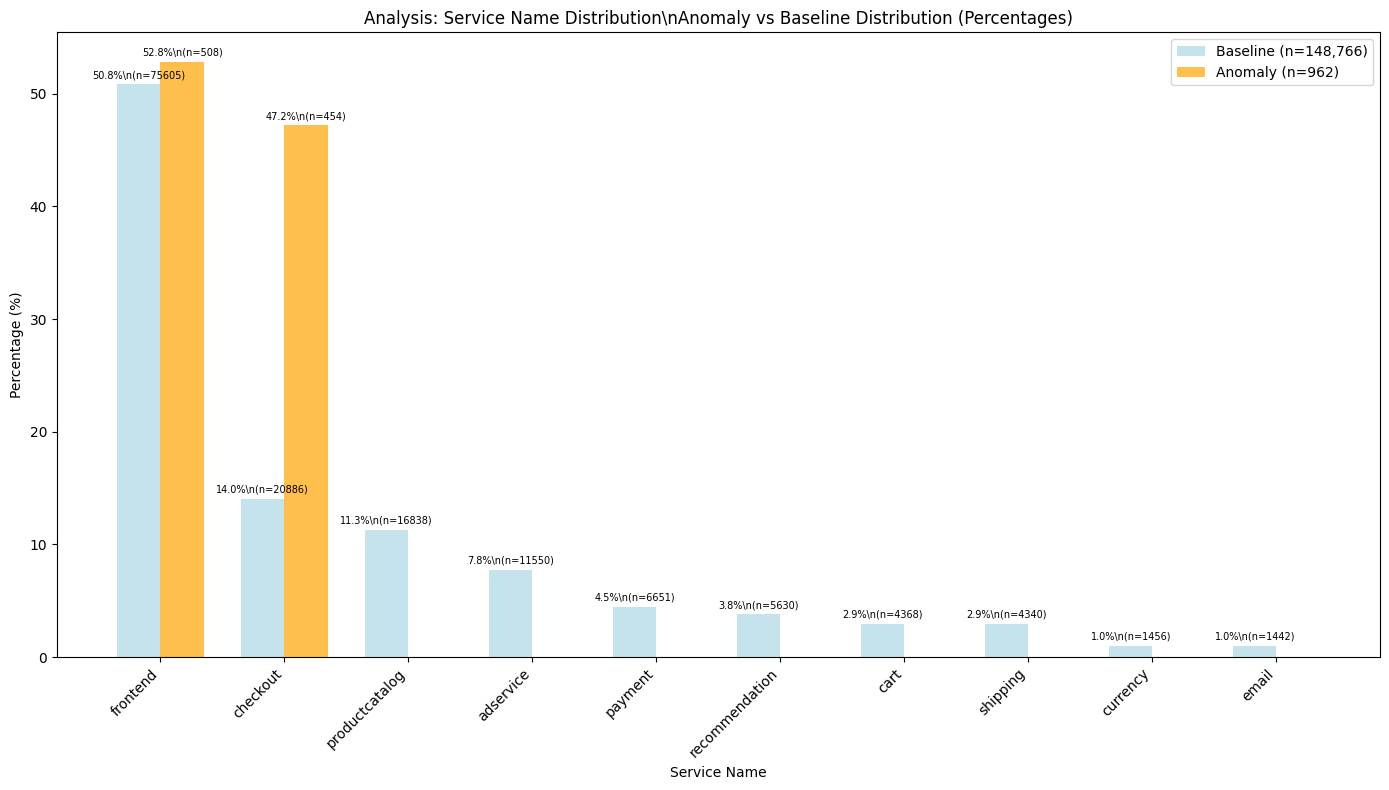

\n🔍 Service Name Analysis:
   📊 Total anomaly instances: 962
   📊 Total baseline instances: 148,766
   🟢 Values over-represented in baseline group:
      • productcatalog: 11.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • adservice: 7.8% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • payment: 4.5% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
\n📋 2. OPERATION NAME ANALYSIS


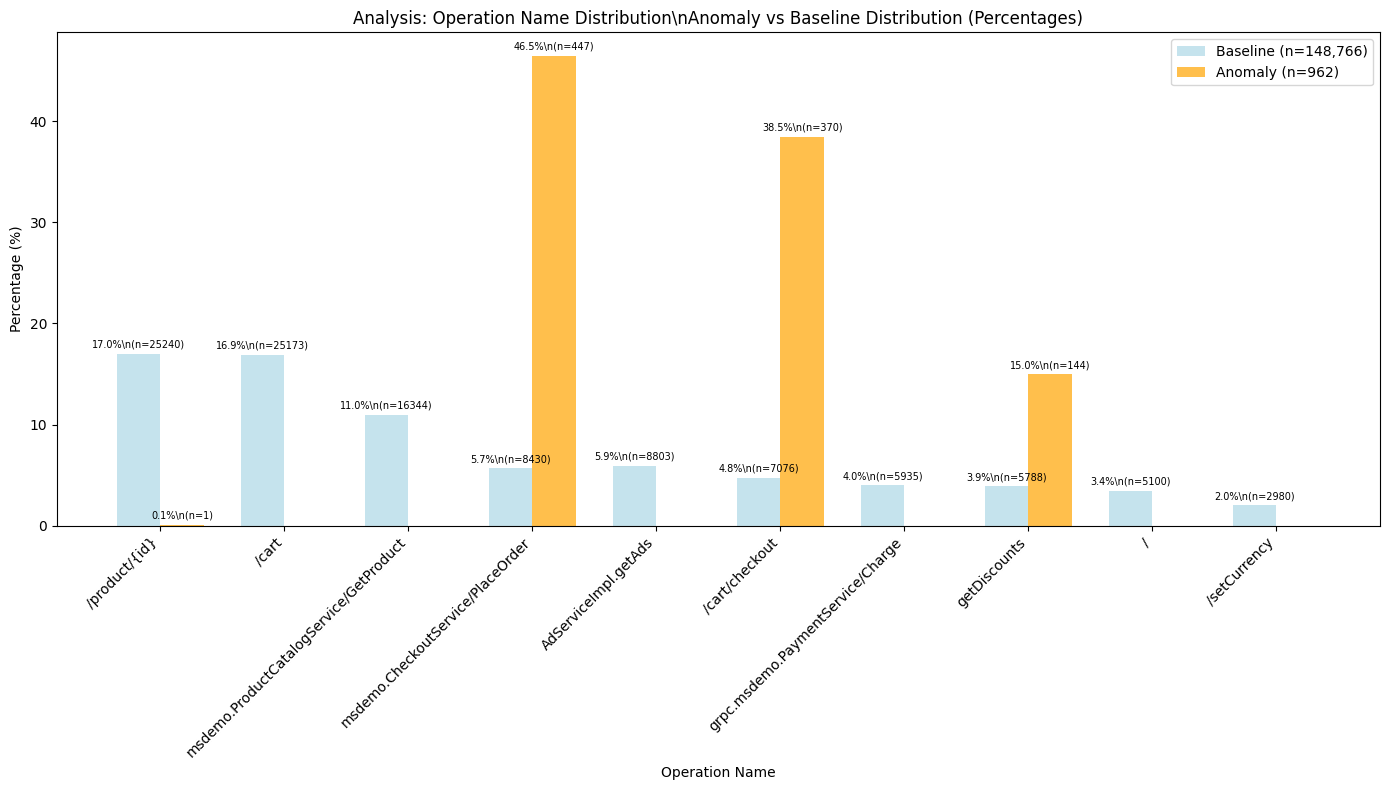

\n🔍 Operation Name Analysis:
   📊 Total anomaly instances: 962
   📊 Total baseline instances: 148,766
   🟢 Values over-represented in baseline group:
      • /product/{id}: 17.0% of baseline vs 0.1% of anomalies (100.0% of this value is baseline)
      • /cart: 16.9% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • msdemo.ProductCatalogService/GetProduct: 11.0% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
\n📋 3. STATUS CODE ANALYSIS


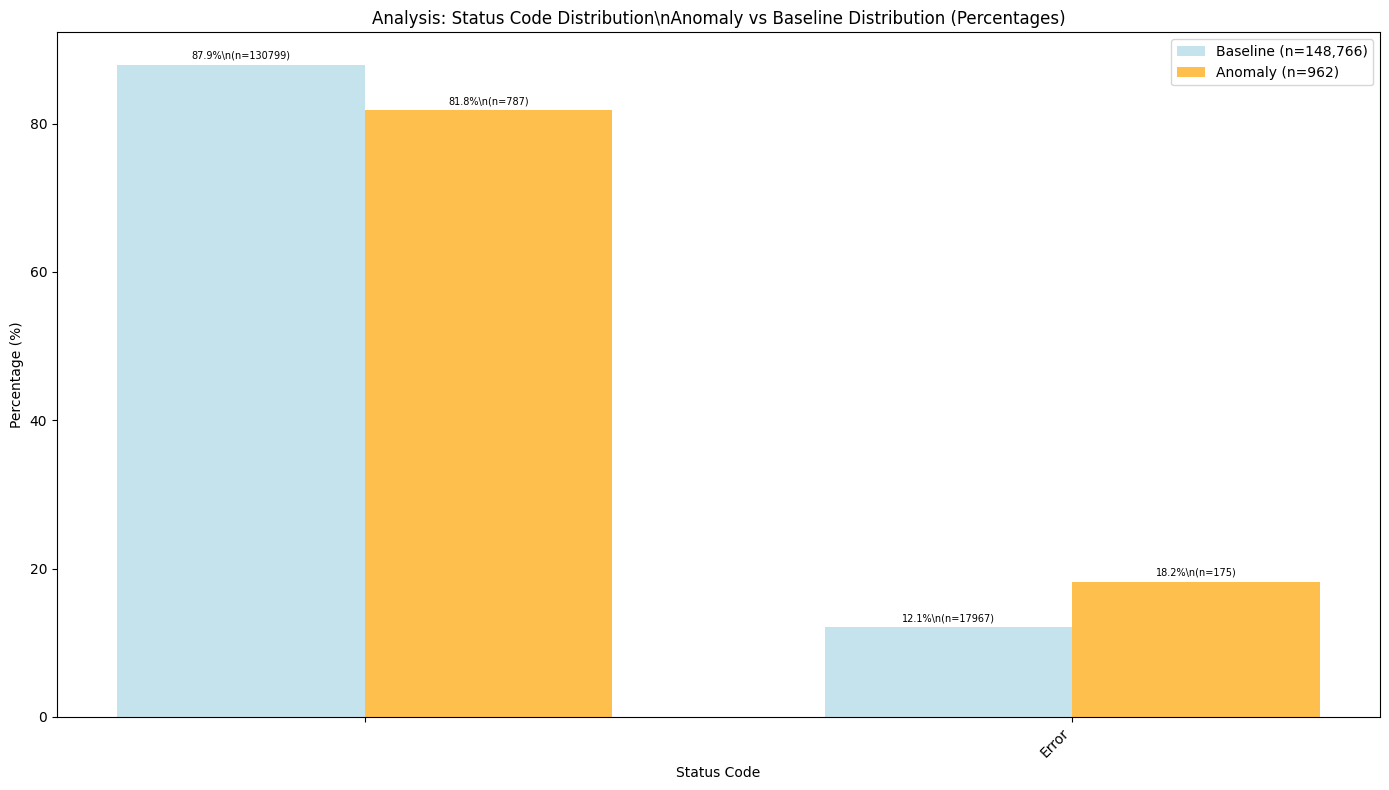

\n🔍 Status Code Analysis:
   📊 Total anomaly instances: 962
   📊 Total baseline instances: 148,766
   🟢 Values over-represented in baseline group:
      • : 87.9% of baseline vs 81.8% of anomalies (99.4% of this value is baseline)
\n📋 4. SUCCESS FLAG ANALYSIS


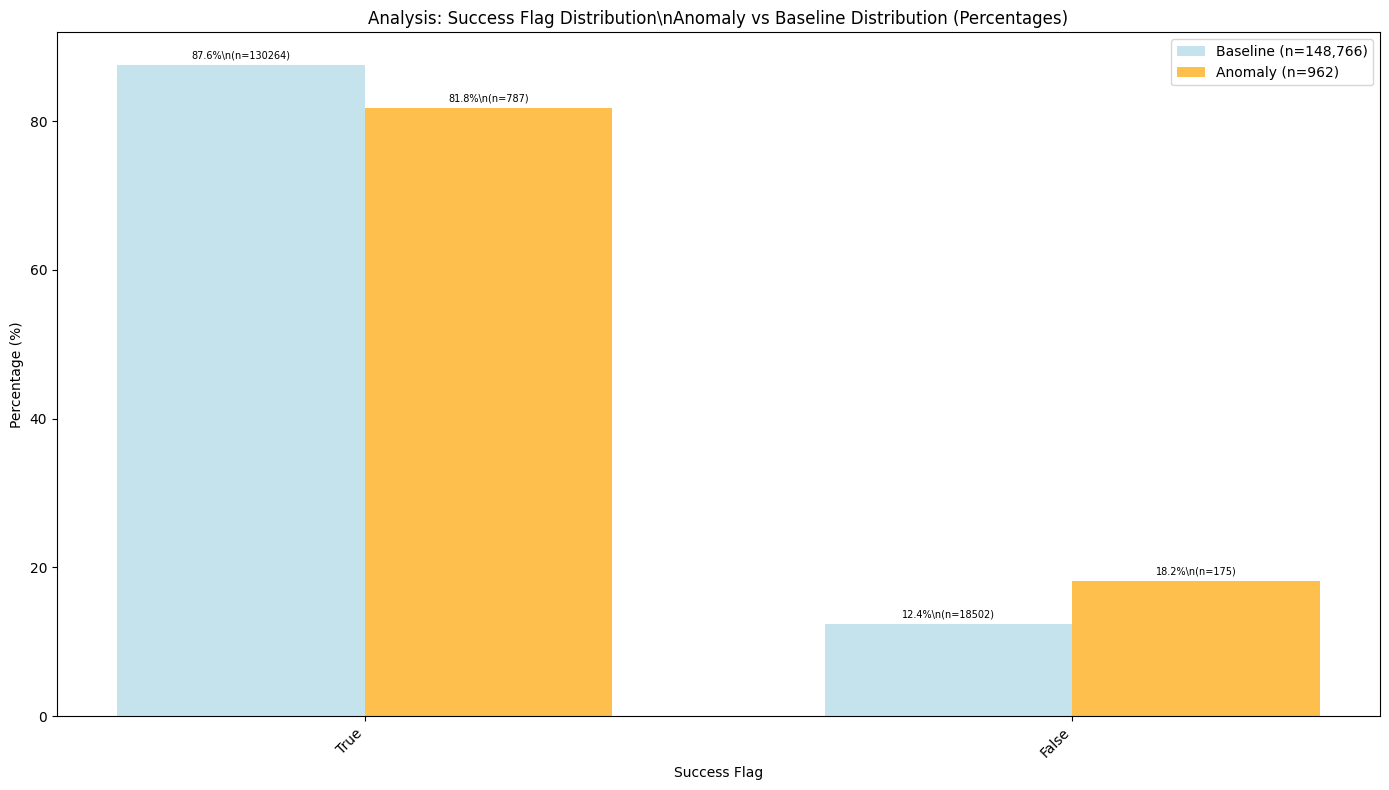

\n🔍 Success Flag Analysis:
   📊 Total anomaly instances: 962
   📊 Total baseline instances: 148,766
   🟢 Values over-represented in baseline group:
      • True: 87.6% of baseline vs 81.8% of anomalies (99.4% of this value is baseline)
\n✅ Paired histograms completed!


In [171]:
# Create paired histograms
print("📊 CREATING PAIRED HISTOGRAMS")
print("=" * 50)

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def create_anomaly_histogram(dimension_name, anomaly_values, baseline_values, title, max_categories=15):
    """
    Create a paired histogram comparing anomaly vs baseline distributions using percentages
    """
    # Get value counts for both groups
    anomaly_counts = Counter(anomaly_values)
    baseline_counts = Counter(baseline_values)
    
    # Calculate total counts for percentage calculation
    total_anomaly = sum(anomaly_counts.values())
    total_baseline = sum(baseline_counts.values())
    
    # Get all unique values and limit to top categories
    all_values = set(anomaly_counts.keys()) | set(baseline_counts.keys())
    
    # Sort by total frequency to show most important categories
    value_totals = {val: anomaly_counts.get(val, 0) + baseline_counts.get(val, 0) for val in all_values}
    top_values = sorted(value_totals.keys(), key=lambda x: value_totals[x], reverse=True)[:max_categories]
    
    # Prepare data for plotting (convert to percentages)
    categories = []
    anomaly_data = []
    baseline_data = []
    anomaly_counts_raw = []
    baseline_counts_raw = []
    
    for value in top_values:
        categories.append(str(value))
        
        # Raw counts for annotations
        anomaly_count = anomaly_counts.get(value, 0)
        baseline_count = baseline_counts.get(value, 0)
        anomaly_counts_raw.append(anomaly_count)
        baseline_counts_raw.append(baseline_count)
        
        # Convert to percentages
        anomaly_pct = (anomaly_count / total_anomaly * 100) if total_anomaly > 0 else 0
        baseline_pct = (baseline_count / total_baseline * 100) if total_baseline > 0 else 0
        
        anomaly_data.append(anomaly_pct)
        baseline_data.append(baseline_pct)
    
    # Create the paired bar chart
    x = np.arange(len(categories))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    bars1 = ax.bar(x - width/2, baseline_data, width, label=f'Baseline (n={total_baseline:,})', color='lightblue', alpha=0.7)
    bars2 = ax.bar(x + width/2, anomaly_data, width, label=f'Anomaly (n={total_anomaly:,})', color='orange', alpha=0.7)
    
    ax.set_xlabel(dimension_name)
    ax.set_ylabel('Percentage (%)')
    ax.set_title(f'Analysis: {title}\\nAnomaly vs Baseline Distribution (Percentages)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=45, ha='right')
    ax.legend()
    
    # Add percentage and count labels on bars
    for i, bar in enumerate(bars1):
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%\\n(n={baseline_counts_raw[i]})',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=7)
    
    for i, bar in enumerate(bars2):
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%\\n(n={anomaly_counts_raw[i]})',
                       xy=(bar.get_x() + bar.get_width() / 2, height),
                       xytext=(0, 3),  # 3 points vertical offset
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    plt.show()
    
    # Print insights
    print(f"\\n🔍 {dimension_name} Analysis:")
    print(f"   📊 Total anomaly instances: {total_anomaly:,}")
    print(f"   📊 Total baseline instances: {total_baseline:,}")
    
    # Identify values that are more prominent in anomaly vs baseline
    anomaly_dominant = []
    baseline_dominant = []
    
    for i, value in enumerate(top_values):
        anomaly_count = anomaly_counts_raw[i]
        baseline_count = baseline_counts_raw[i]
        anomaly_pct = anomaly_data[i]
        baseline_pct = baseline_data[i]
        
        total = anomaly_count + baseline_count
        if total > 0:
            # Calculate what percentage of this value's total occurrences are anomalous
            anomaly_share = (anomaly_count / total) * 100
            
            # Check if this value is over-represented in anomaly group
            if anomaly_pct > baseline_pct and anomaly_share > 20:
                anomaly_dominant.append((value, anomaly_pct, baseline_pct, anomaly_share, anomaly_count, baseline_count))
            # Check if this value is over-represented in baseline group  
            elif baseline_pct > anomaly_pct and (100 - anomaly_share) > 80:
                baseline_dominant.append((value, baseline_pct, anomaly_pct, 100 - anomaly_share, baseline_count, anomaly_count))
    
    if anomaly_dominant:
        print(f"   🚨 Values over-represented in anomaly group:")
        for value, a_pct, b_pct, share, a_count, b_count in sorted(anomaly_dominant, key=lambda x: x[1], reverse=True):
            print(f"      • {value}: {a_pct:.1f}% of anomalies vs {b_pct:.1f}% of baseline ({share:.1f}% of this value is anomalous)")
    
    if baseline_dominant:
        print(f"   🟢 Values over-represented in baseline group:")
        for value, b_pct, a_pct, share, b_count, a_count in sorted(baseline_dominant, key=lambda x: x[1], reverse=True)[:3]:  # Top 3
            print(f"      • {value}: {b_pct:.1f}% of baseline vs {a_pct:.1f}% of anomalies ({share:.1f}% of this value is baseline)")
    
    return fig

# Now creating paired histograms for each dimension
print(f"\\n🎨 Creating paired histograms...")
print(f"📊 Data available: {len(df_anomaly)} anomaly traces, {len(df_baseline)} baseline traces")

if len(df_anomaly) > 0 and len(df_baseline) > 0:
    
    # 1. SERVICE NAME Analysis
    print(f"\\n📋 1. SERVICE NAME ANALYSIS")
    create_anomaly_histogram(
        'Service Name',
        df_anomaly['ServiceName'].fillna('NULL'),
        df_baseline['ServiceName'].fillna('NULL'),
        'Service Name Distribution'
    )
    
    # 2. OPERATION NAME Analysis (limit to top 10 for readability)
    print(f"\\n📋 2. OPERATION NAME ANALYSIS")
    create_anomaly_histogram(
        'Operation Name',
        df_anomaly['Name'].fillna('NULL'),
        df_baseline['Name'].fillna('NULL'),
        'Operation Name Distribution',
        max_categories=10
    )
    
    # 3. STATUS CODE Analysis
    if 'StatusCode' in df_anomaly.columns:
        print(f"\\n📋 3. STATUS CODE ANALYSIS")
        create_anomaly_histogram(
            'Status Code',
            df_anomaly['StatusCode'].fillna('NULL'),
            df_baseline['StatusCode'].fillna('NULL'),
            'Status Code Distribution'
        )
    
    # 4. SUCCESS FLAG Analysis
    if 'Success' in df_anomaly.columns:
        print(f"\\n📋 4. SUCCESS FLAG ANALYSIS")
        create_anomaly_histogram(
            'Success Flag',
            df_anomaly['Success'].fillna('NULL'),
            df_baseline['Success'].fillna('NULL'),
            'Success Flag Distribution'
        )

    print(f"\\n✅ Paired histograms completed!")
    
else:
    print(f"⚠️ Insufficient data for histogram analysis")
    print(f"   Anomaly traces: {len(df_anomaly) if 'df_anomaly' in locals() else 0}")
    print(f"   Baseline traces: {len(df_baseline) if 'df_baseline' in locals() else 0}")

## 📋 Attributes Analysis
Now let's analyze the individual attributes to identify differences between anomaly and baseline groups

In [172]:
# Identify and analyze attribute columns for comparison
import pandas as pd

print("🔍 ANALYZING ATTRIBUTE COLUMNS")
print("=" * 50)

# Find all attribute columns
if 'df_anomaly' in locals() and 'df_baseline' in locals():
    # Get all columns that start with 'attr_' but avoid duplicates
    attr_columns = [col for col in df_anomaly.columns if col.startswith('attr_')]
    
    # Remove duplicates by using unique column names only
    unique_attr_columns = []
    seen_columns = set()
    for col in attr_columns:
        if col not in seen_columns:
            unique_attr_columns.append(col)
            seen_columns.add(col)
    
    print(f"📊 Found {len(attr_columns)} attribute columns ({len(unique_attr_columns)} unique)")
    
    if len(unique_attr_columns) > 0:
        # Analyze coverage and variance for each attribute
        print(f"\n📈 ATTRIBUTE COVERAGE ANALYSIS:")
        attr_stats = []
        
        for attr_col in unique_attr_columns:
            try:
                # Get the first occurrence of the column if there are duplicates
                anomaly_series = df_anomaly[attr_col]
                baseline_series = df_baseline[attr_col]
                
                # If we get a DataFrame due to duplicate columns, take the first column
                if isinstance(anomaly_series, pd.DataFrame):
                    anomaly_series = anomaly_series.iloc[:, 0]
                if isinstance(baseline_series, pd.DataFrame):
                    baseline_series = baseline_series.iloc[:, 0]
                
                # Calculate coverage in both groups  
                anomaly_coverage = (anomaly_series.notna().sum() / len(df_anomaly) * 100)
                baseline_coverage = (baseline_series.notna().sum() / len(df_baseline) * 100)
                
                # Calculate unique values
                anomaly_unique = anomaly_series.dropna().nunique()
                baseline_unique = baseline_series.dropna().nunique()
                
                # Calculate total non-null values
                anomaly_count = anomaly_series.notna().sum()
                baseline_count = baseline_series.notna().sum()
                total_values = anomaly_count + baseline_count
            
                attr_stats.append({
                    'attribute': attr_col,
                    'anomaly_coverage': anomaly_coverage,
                    'baseline_coverage': baseline_coverage,
                    'anomaly_unique': anomaly_unique,
                    'baseline_unique': baseline_unique,
                    'total_values': total_values,
                    'coverage_diff': abs(anomaly_coverage - baseline_coverage)
                })
            except Exception as e:
                print(f"   ⚠️ Error processing {attr_col}: {e}")
                continue
        
        # Sort by total values (data richness) and coverage difference
        if len(attr_stats) > 0:
            attr_stats.sort(key=lambda x: (x['total_values'], x['coverage_diff']), reverse=True)
            
            print(f"   {'Attribute':<35} | {'Anomaly Cov':<12} | {'Baseline Cov':<13} | {'A Unique':<9} | {'B Unique':<9} | {'Total Values':<12}")
            print(f"   {'-'*35} | {'-'*12} | {'-'*13} | {'-'*9} | {'-'*9} | {'-'*12}")
            
            top_attributes = []
            for i, stat in enumerate(attr_stats):  # Show attributes
                attr_name = stat['attribute'].replace('attr_', '')[:50]
                print(f"   {attr_name:<35} | {stat['anomaly_coverage']:>9.1f}% | {stat['baseline_coverage']:>10.1f}% | {stat['anomaly_unique']:>9} | {stat['baseline_unique']:>9} | {stat['total_values']:>12,}")
                
                # Select attributes with good coverage and reasonable unique values for analysis
                if (#stat['total_values'] >= 50 and  # Minimum data points
                    stat['anomaly_unique'] > 1): #and #stat['baseline_unique'] > 1 and  # Has variety
                    #stat['anomaly_unique'] <= 20 and stat['baseline_unique'] <= 20):  # Not too sparse
                    top_attributes.append(stat['attribute'])
            
            print(f"\n🎯 Selected {len(top_attributes)} attributes for detailed analysis:")
            for i, attr in enumerate(top_attributes[:15], 1):  # Limit to top 10 for performance
                attr_display = attr.replace('attr_', '')
                print(f"   {i}. {attr_display}")
                
            # Store for use in visualization
            actual_attr_columns = top_attributes[:15]  # Limit to prevent too many charts
            print(f"\n✅ Ready to create visualizations for {len(actual_attr_columns)} key attributes")
        else:
            print("⚠️ No valid attribute statistics could be calculated")
            actual_attr_columns = []
        
    else:
        print("⚠️ No attribute columns found in the dataset")
        actual_attr_columns = []
else:
    print("⚠️ Anomaly and baseline groups not found. Please run data segmentation first.")
    actual_attr_columns = []

🔍 ANALYZING ATTRIBUTE COLUMNS
📊 Found 54 attribute columns (54 unique)

📈 ATTRIBUTE COVERAGE ANALYSIS:
   Attribute                           | Anomaly Cov  | Baseline Cov  | A Unique  | B Unique  | Total Values
   ----------------------------------- | ------------ | ------------- | --------- | --------- | ------------
   net_sock_peer_addr                  |      78.4% |       70.7% |         3 |        18 |      105,907
   net_sock_peer_port                  |      78.4% |       70.7% |         7 |       651 |      105,907
   app_user_id                         |      85.8% |       52.8% |       154 |     13598 |       79,322
   app_request_id                      |      70.8% |       48.9% |       374 |     65635 |       73,390
   app_build_id                        |      70.8% |       48.9% |         1 |         2 |       73,390
   http_method                         |      38.6% |       46.4% |         2 |         7 |       69,435
   http_target                         |      38.

📊 CREATING ATTRIBUTE PAIRED HISTOGRAMS
🎨 Creating paired histograms for 13 attributes...
📊 Data available: 962 anomaly traces, 148766 baseline traces

📋 1. NET SOCK PEER ADDR ANALYSIS


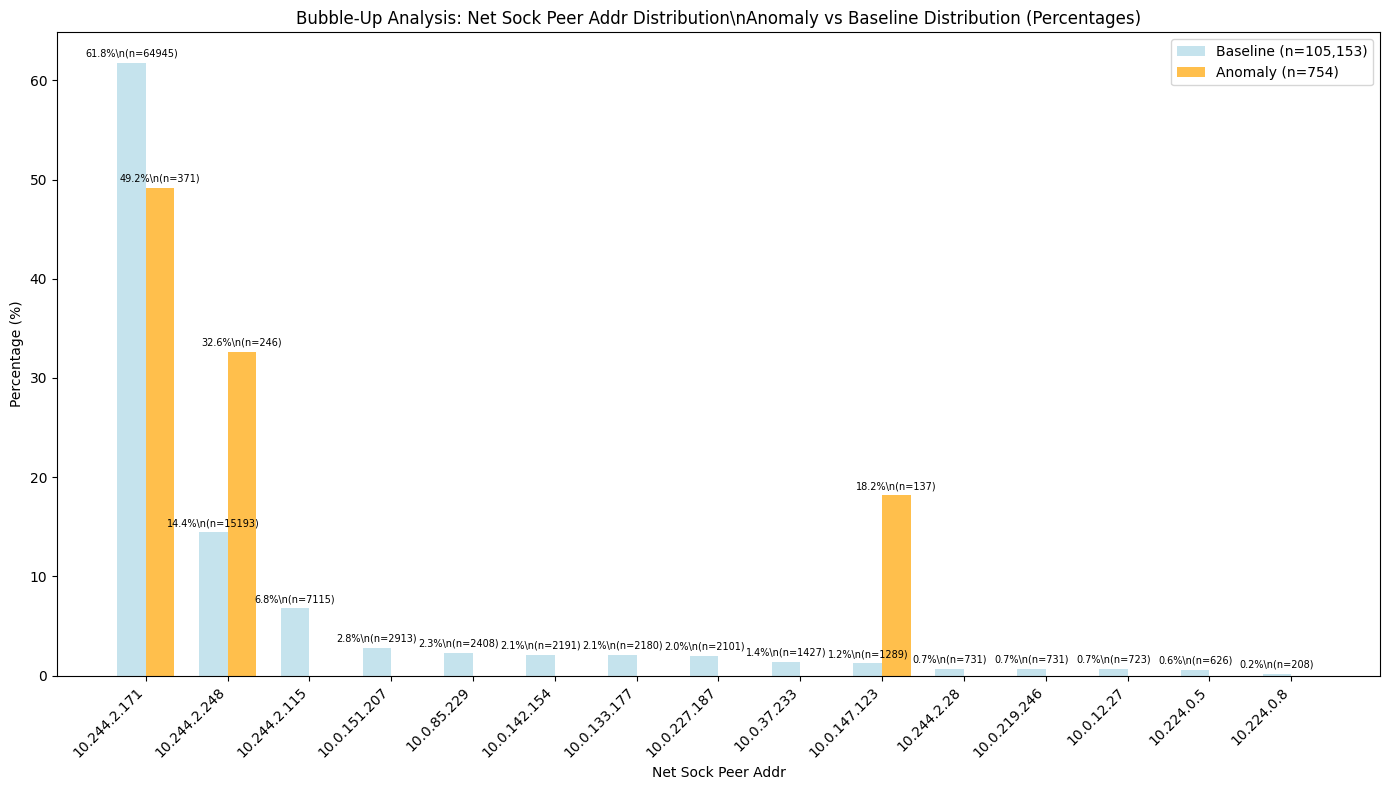

\n🔍 Net Sock Peer Addr Analysis:
   📊 Total anomaly instances: 754
   📊 Total baseline instances: 105,153
   🟢 Values over-represented in baseline group:
      • 10.244.2.171: 61.8% of baseline vs 49.2% of anomalies (99.4% of this value is baseline)
      • 10.244.2.115: 6.8% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 10.0.151.207: 2.8% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 2. NET SOCK PEER PORT ANALYSIS
   📊 Found 651 unique values for Net Sock Peer Port. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 102,598 total instances)


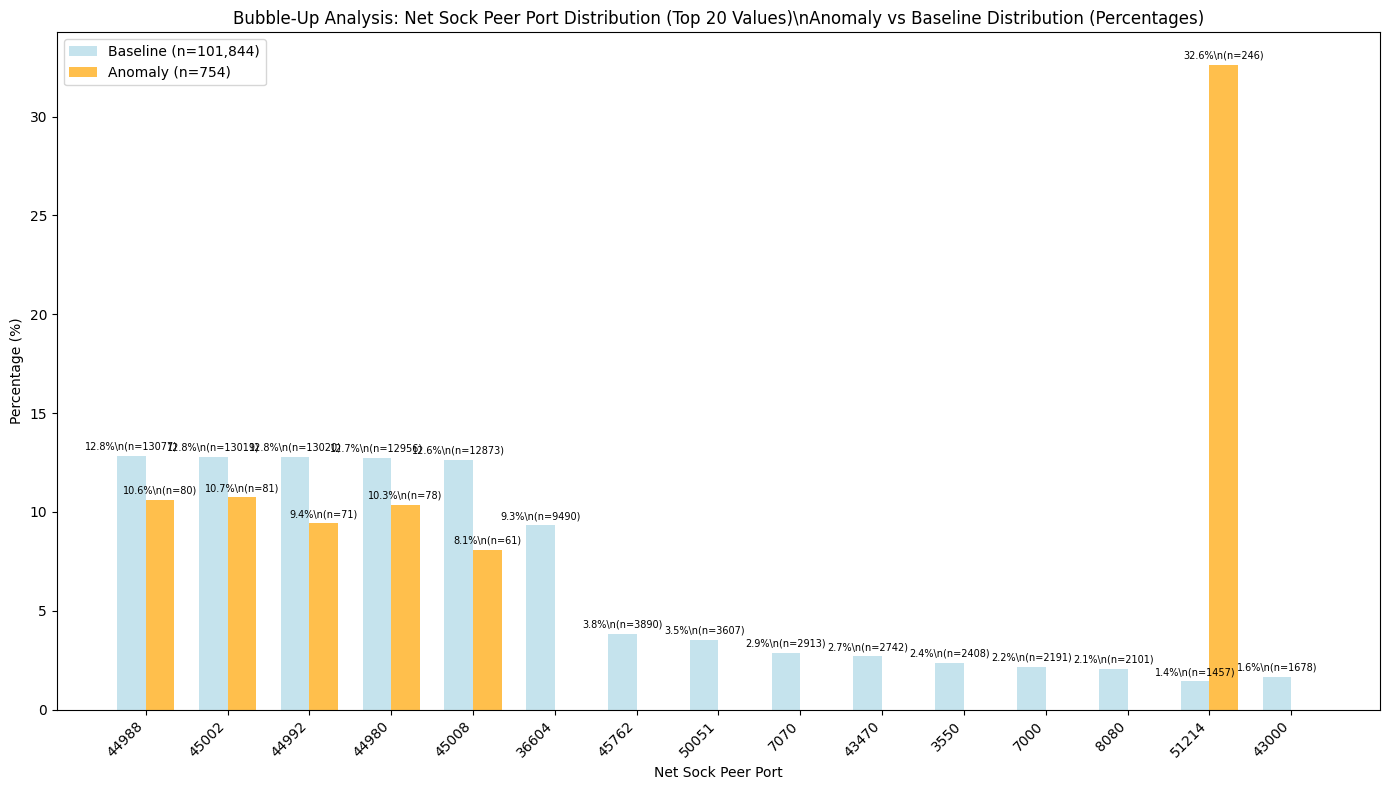

\n🔍 Net Sock Peer Port Analysis:
   📊 Total anomaly instances: 754
   📊 Total baseline instances: 101,844
   🟢 Values over-represented in baseline group:
      • 44988: 12.8% of baseline vs 10.6% of anomalies (99.4% of this value is baseline)
      • 44992: 12.8% of baseline vs 9.4% of anomalies (99.5% of this value is baseline)
      • 45002: 12.8% of baseline vs 10.7% of anomalies (99.4% of this value is baseline)

📋 3. APP USER ID ANALYSIS
   📊 Found 13599 unique values for App User Id. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 12,269 total instances)


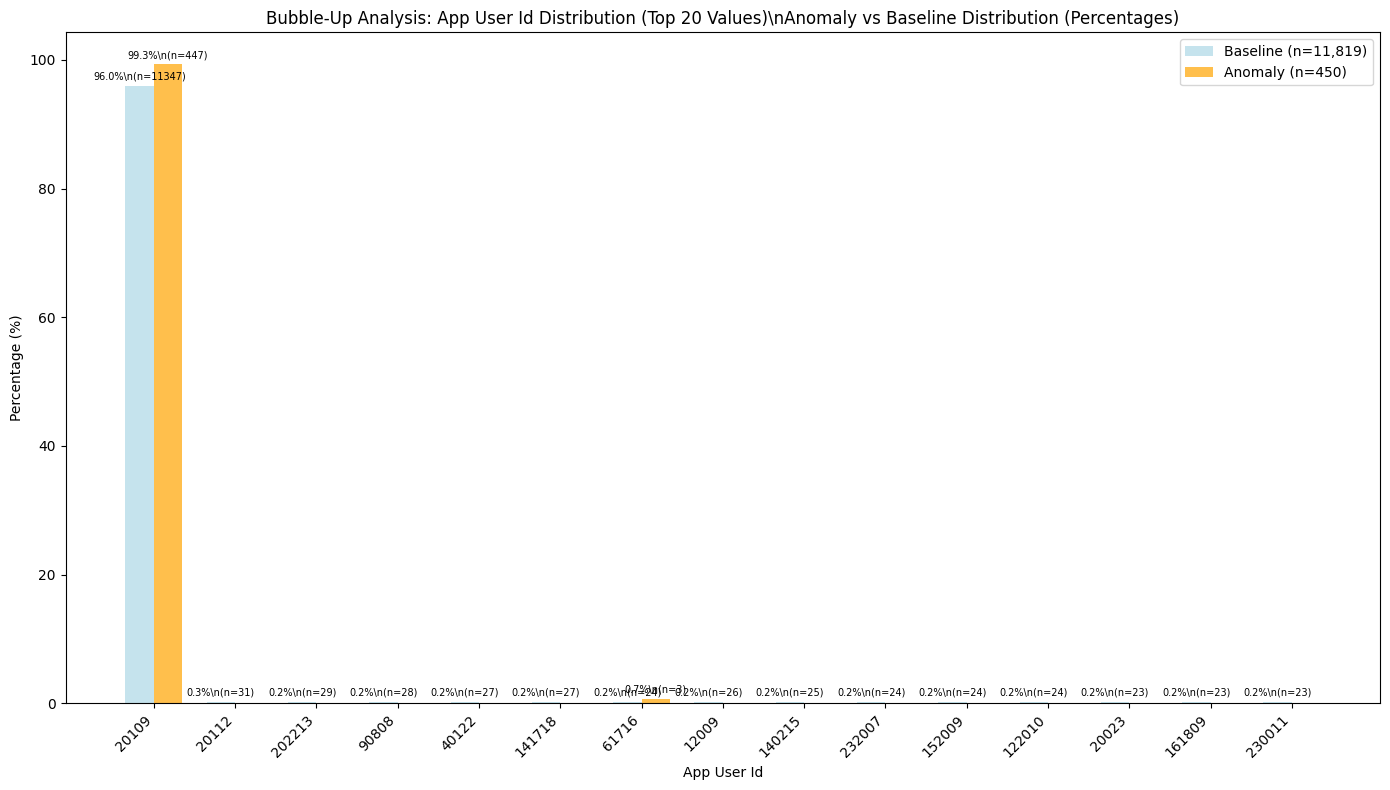

\n🔍 App User Id Analysis:
   📊 Total anomaly instances: 450
   📊 Total baseline instances: 11,819
   🟢 Values over-represented in baseline group:
      • 20112: 0.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 202213: 0.2% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 90808: 0.2% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 4. APP REQUEST ID ANALYSIS
   📊 Found 65946 unique values for App Request Id. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 40 total instances)
   🔝 Using top 20 values (representing 40 total instances)


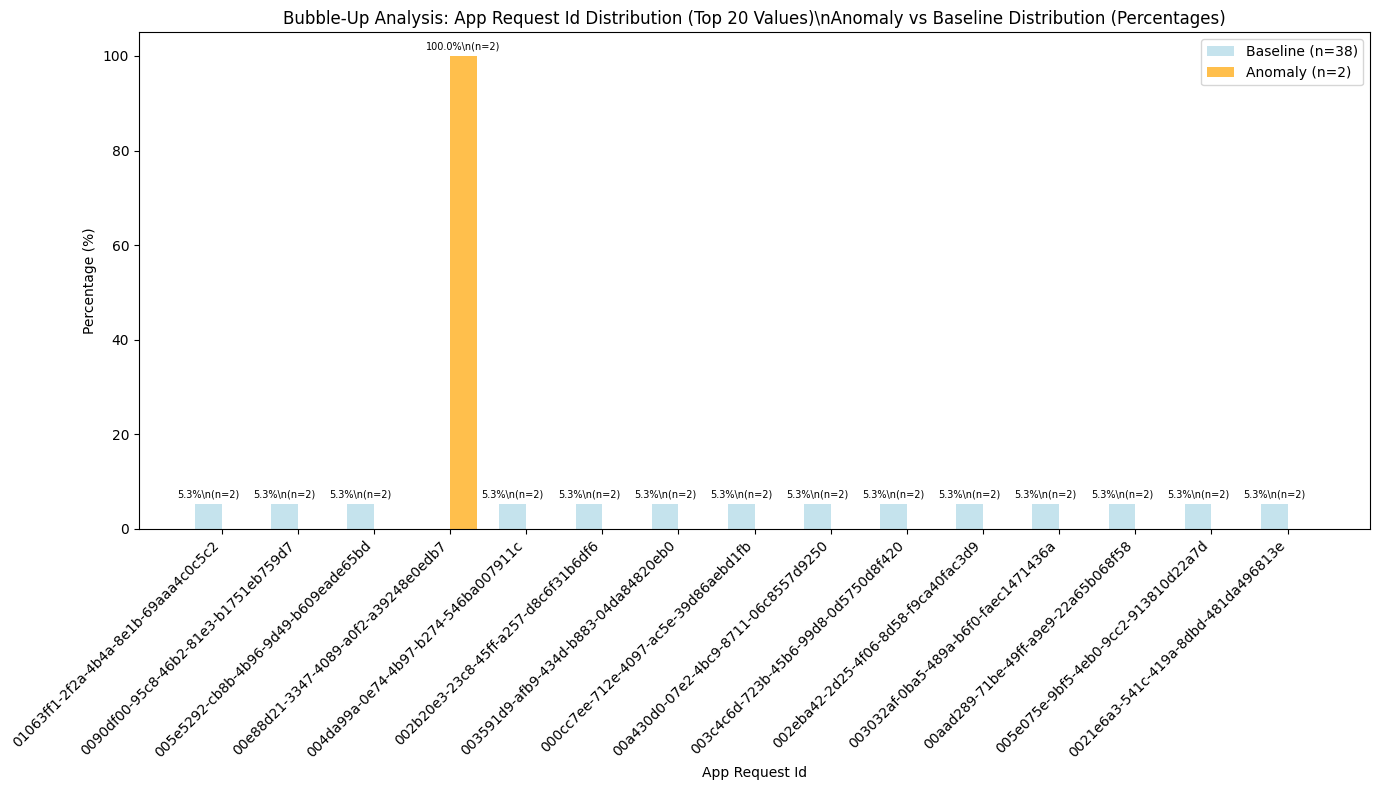

\n🔍 App Request Id Analysis:
   📊 Total anomaly instances: 2
   📊 Total baseline instances: 38
   🚨 Values over-represented in anomaly group:
      • 00e88d21-3347-4089-a0f2-a39248e0edb7: 100.0% of anomalies vs 0.0% of baseline (100.0% of this value is anomalous)
   🟢 Values over-represented in baseline group:
      • 01063ff1-2f2a-4b4a-8e1b-69aaa4c0c5c2: 5.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 0090df00-95c8-46b2-81e3-b1751eb759d7: 5.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 005e5292-cb8b-4b96-9d49-b609eade65bd: 5.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 5. HTTP METHOD ANALYSIS


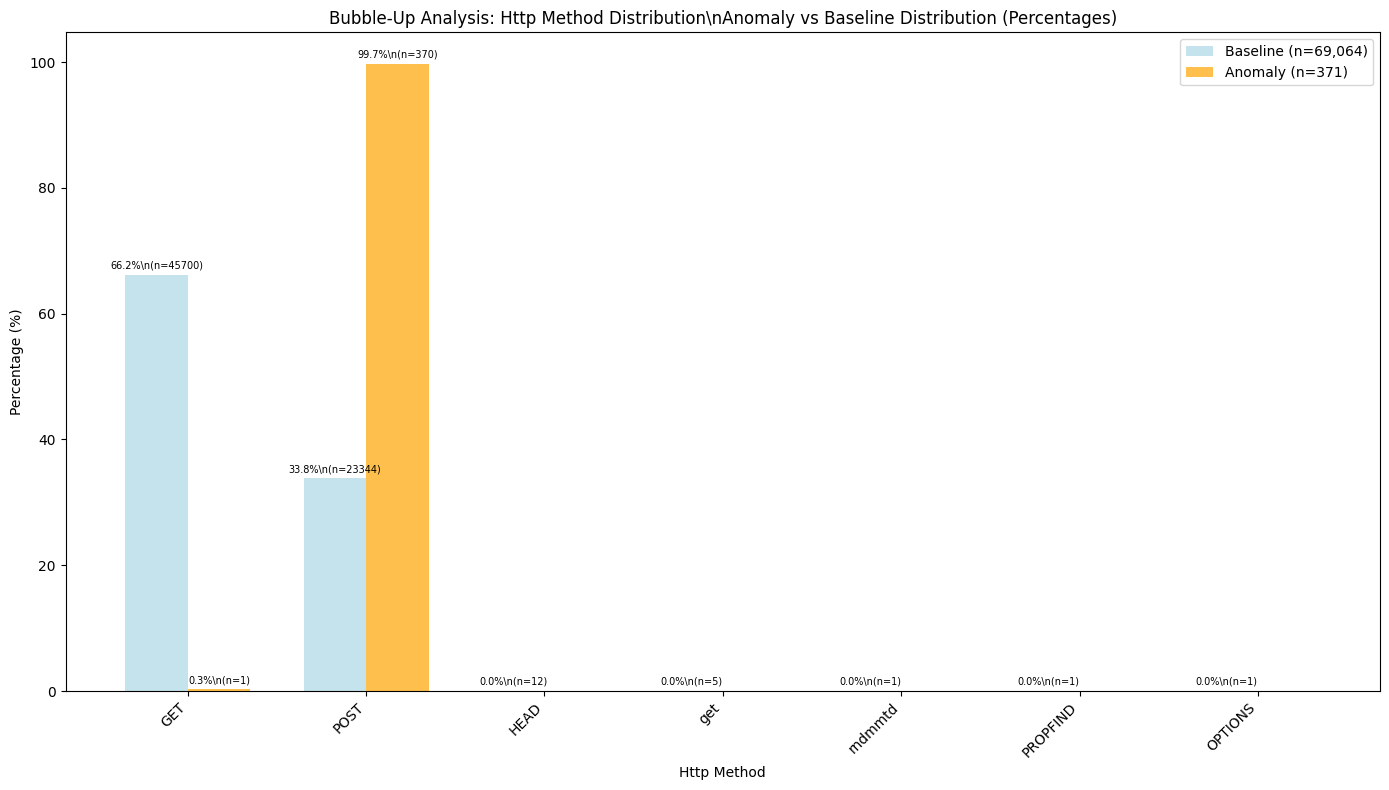

\n🔍 Http Method Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 69,064
   🟢 Values over-represented in baseline group:
      • GET: 66.2% of baseline vs 0.3% of anomalies (100.0% of this value is baseline)
      • HEAD: 0.0% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • get: 0.0% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 6. HTTP TARGET ANALYSIS
   📊 Found 572 unique values for Http Target. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 68,851 total instances)


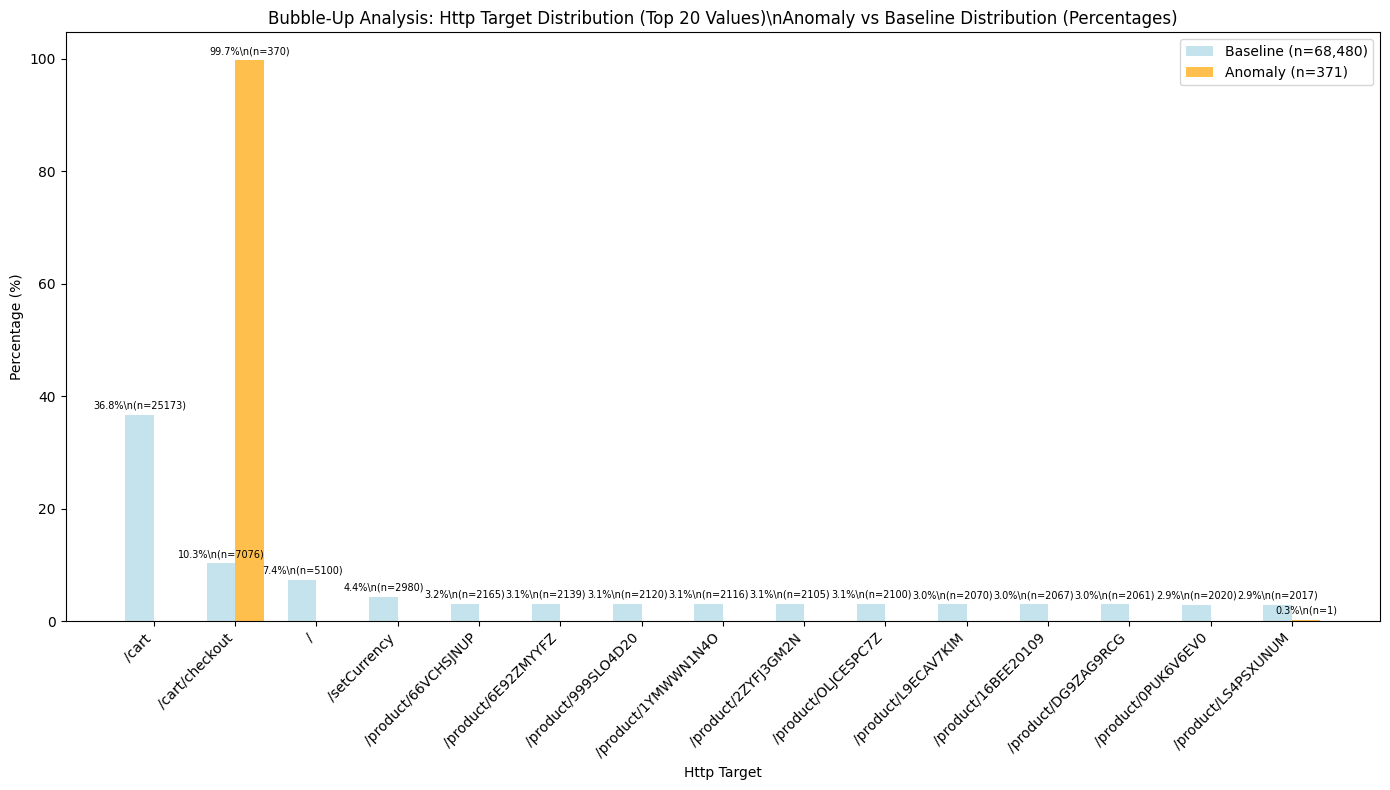

\n🔍 Http Target Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 68,480
   🟢 Values over-represented in baseline group:
      • /cart: 36.8% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • /: 7.4% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • /setCurrency: 4.4% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 7. HTTP STATUS CODE ANALYSIS


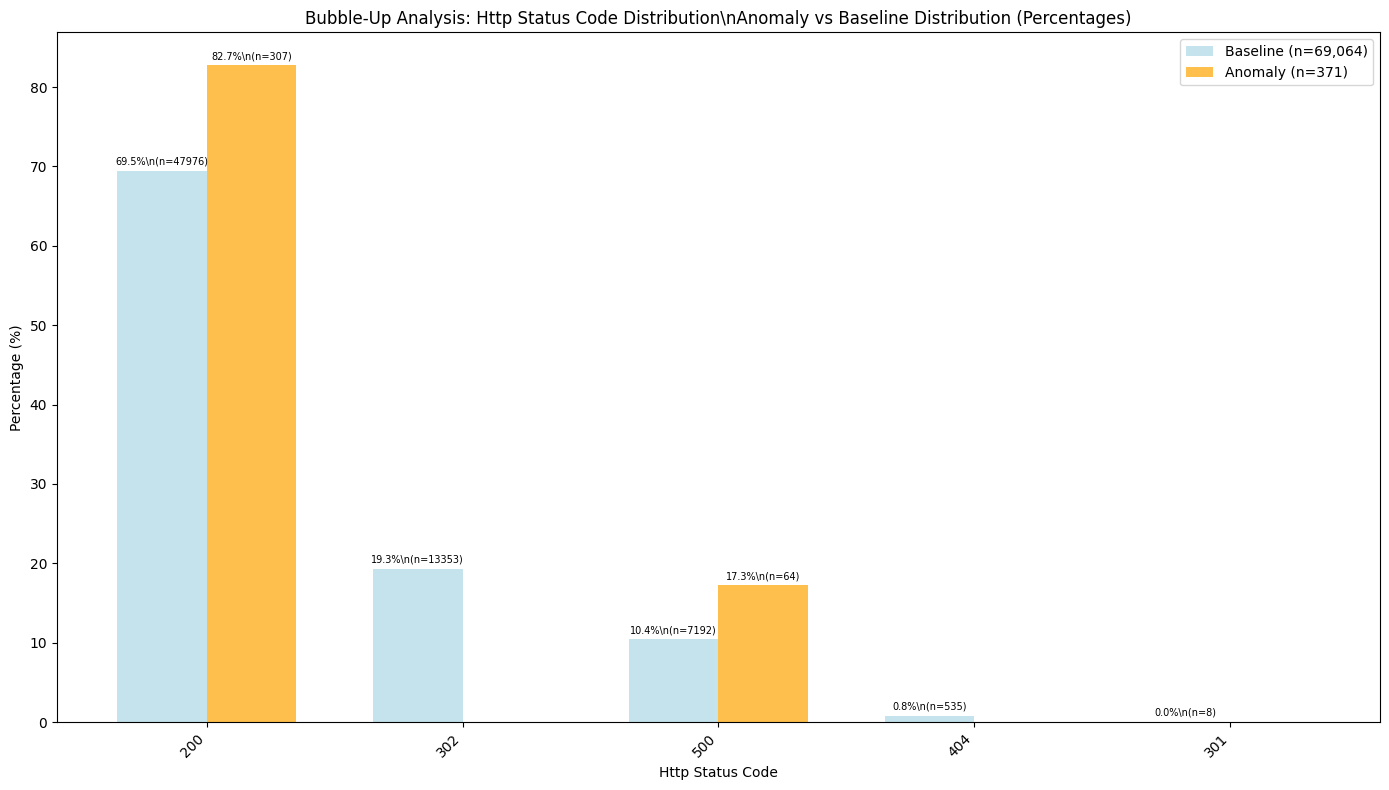

\n🔍 Http Status Code Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 69,064
   🟢 Values over-represented in baseline group:
      • 302: 19.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 404: 0.8% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 301: 0.0% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 8. HTTP ROUTE ANALYSIS


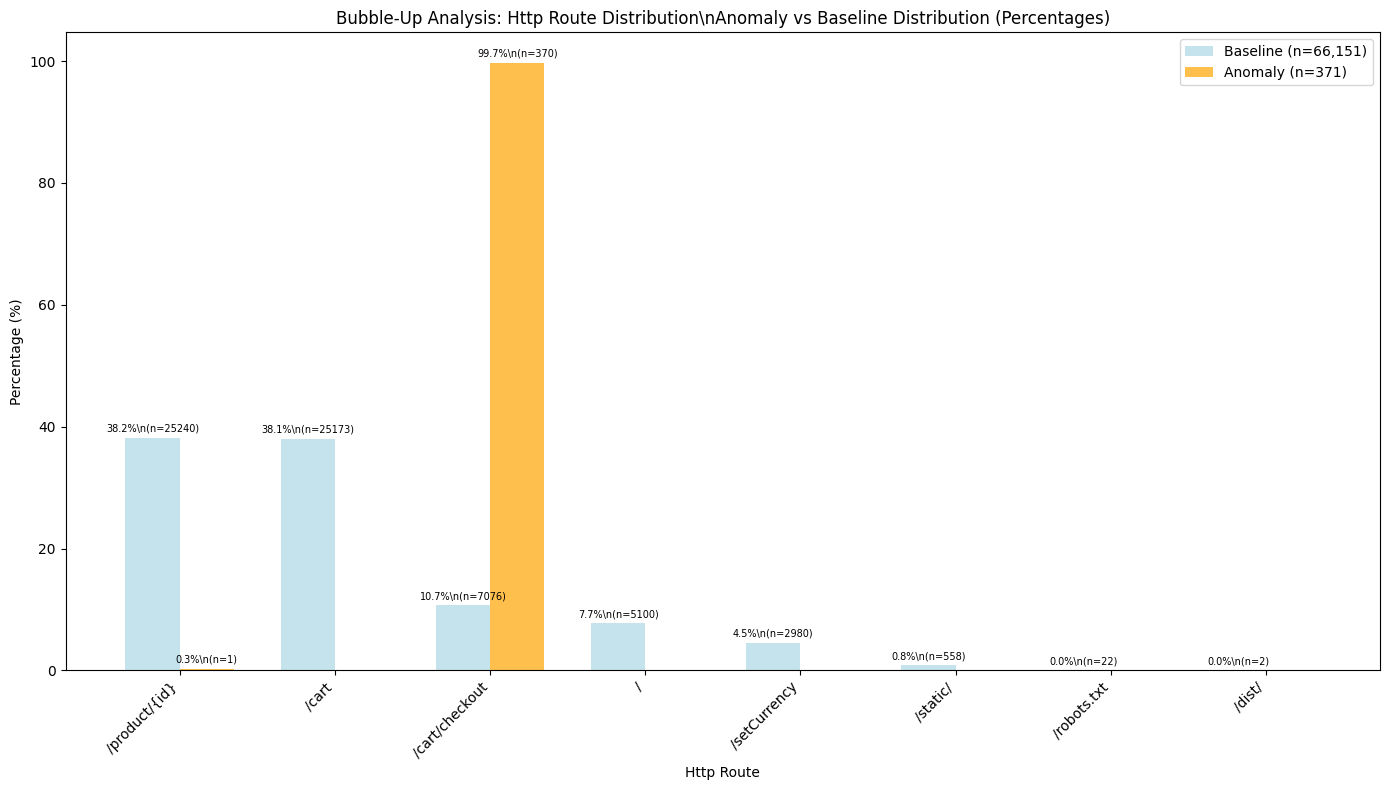

\n🔍 Http Route Analysis:
   📊 Total anomaly instances: 371
   📊 Total baseline instances: 66,151
   🟢 Values over-represented in baseline group:
      • /product/{id}: 38.2% of baseline vs 0.3% of anomalies (100.0% of this value is baseline)
      • /cart: 38.1% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • /: 7.7% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 9. RPC GRPC STATUS CODE ANALYSIS


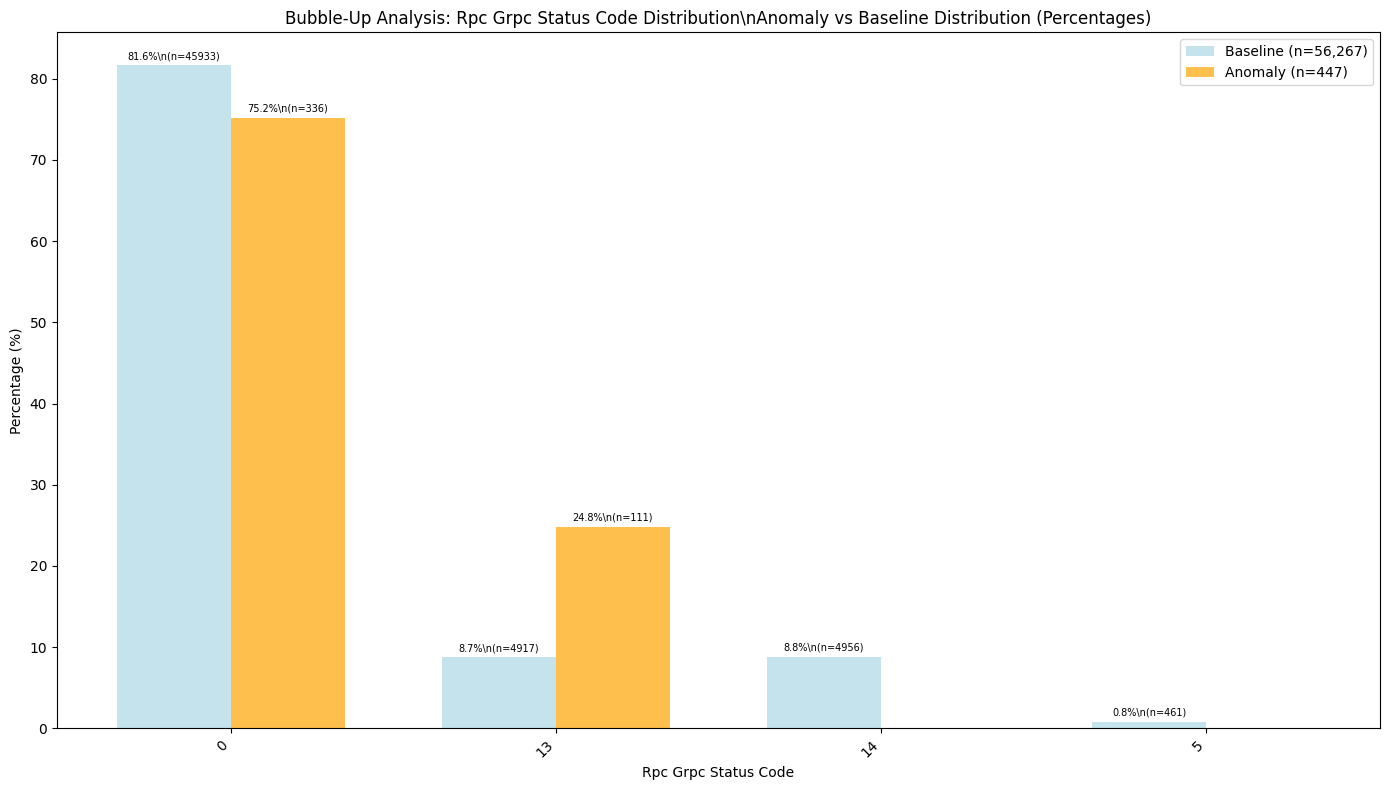

\n🔍 Rpc Grpc Status Code Analysis:
   📊 Total anomaly instances: 447
   📊 Total baseline instances: 56,267
   🟢 Values over-represented in baseline group:
      • 0: 81.6% of baseline vs 75.2% of anomalies (99.3% of this value is baseline)
      • 14: 8.8% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 5: 0.8% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 10. NUM PRODUCTS ANALYSIS


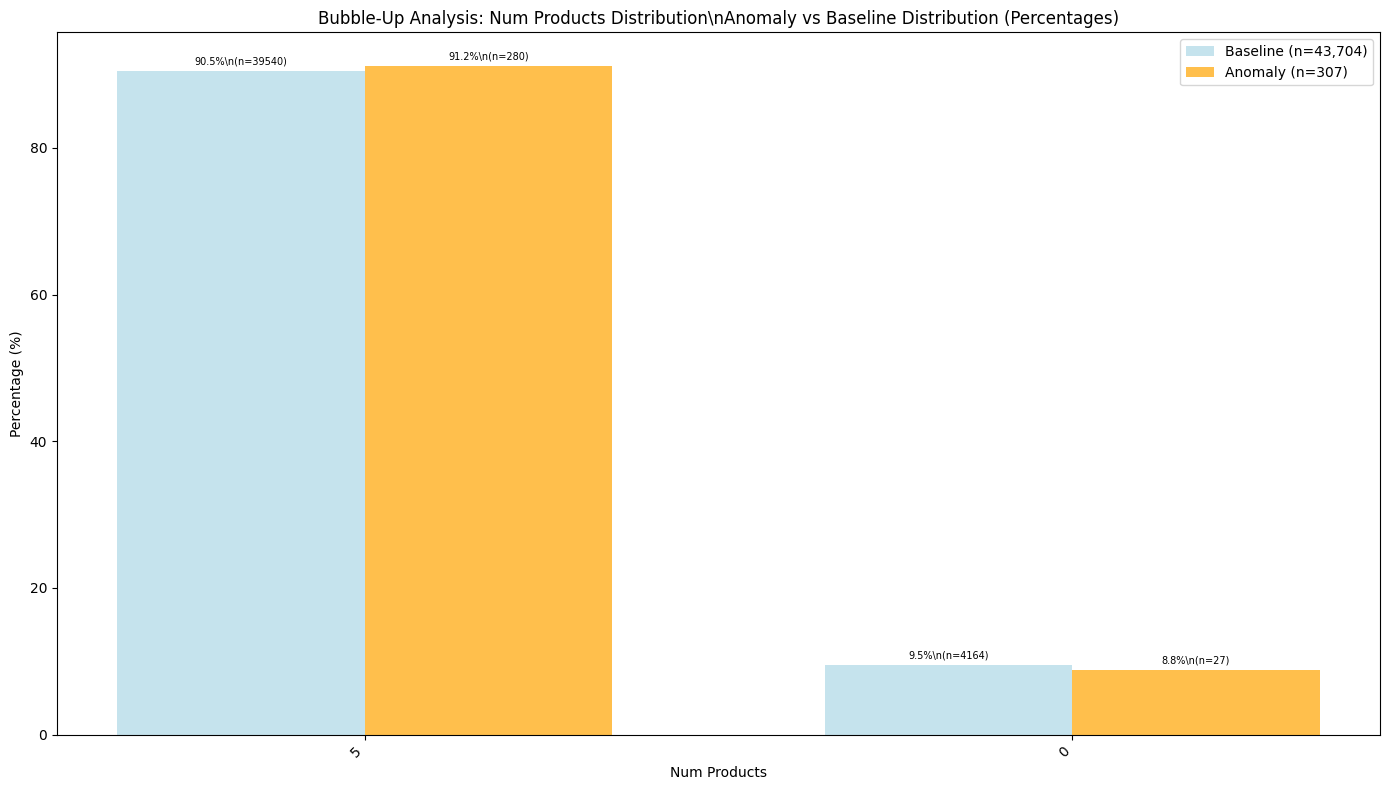

\n🔍 Num Products Analysis:
   📊 Total anomaly instances: 307
   📊 Total baseline instances: 43,704
   🟢 Values over-represented in baseline group:
      • 0: 9.5% of baseline vs 8.8% of anomalies (99.4% of this value is baseline)

📋 11. APP CACHE SIZE ANALYSIS
   📊 Found 7382 unique values for App Cache Size. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 40 total instances)


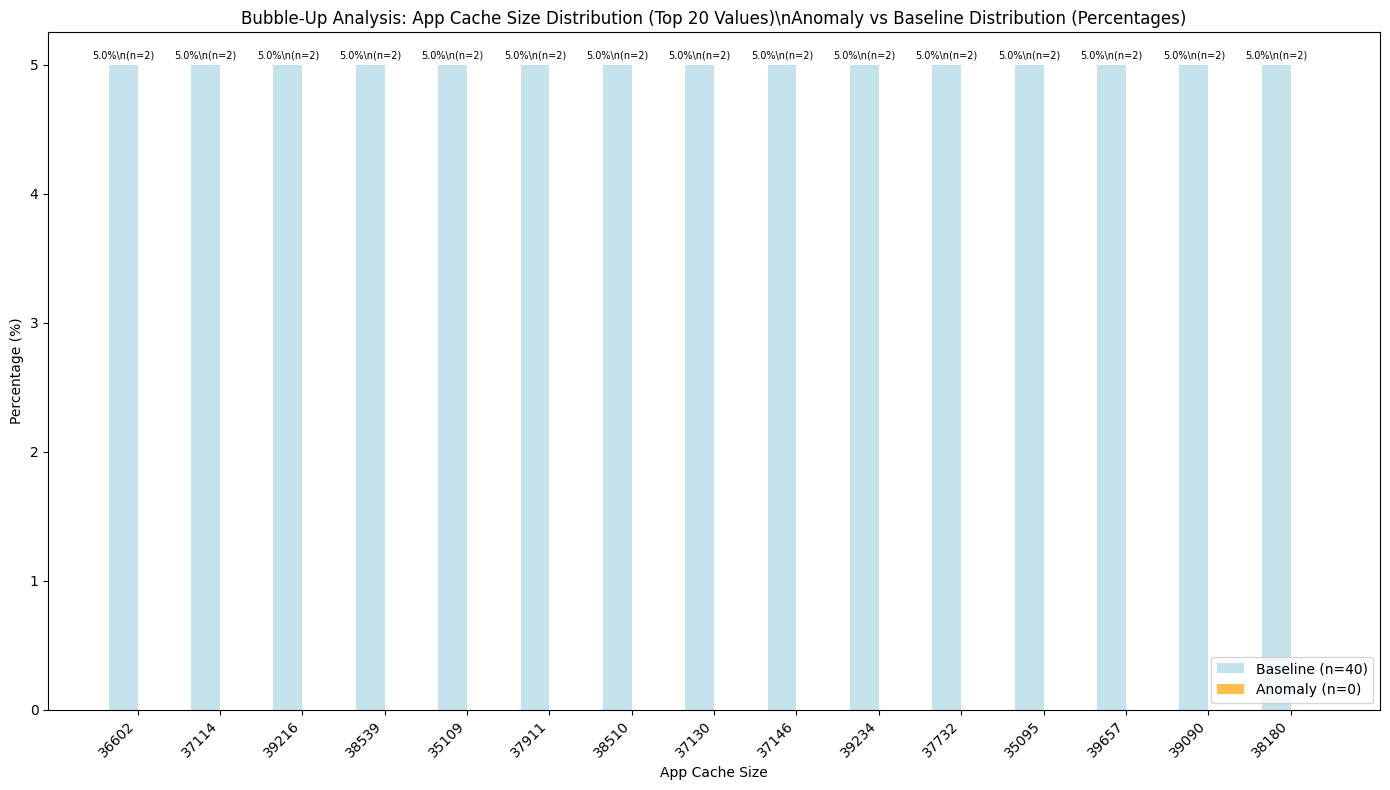

\n🔍 App Cache Size Analysis:
   📊 Total anomaly instances: 0
   📊 Total baseline instances: 40
   🟢 Values over-represented in baseline group:
      • 36602: 5.0% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 37114: 5.0% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 39216: 5.0% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 12. APP ORDER ID ANALYSIS
   📊 Found 7450 unique values for App Order Id. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 20 total instances)


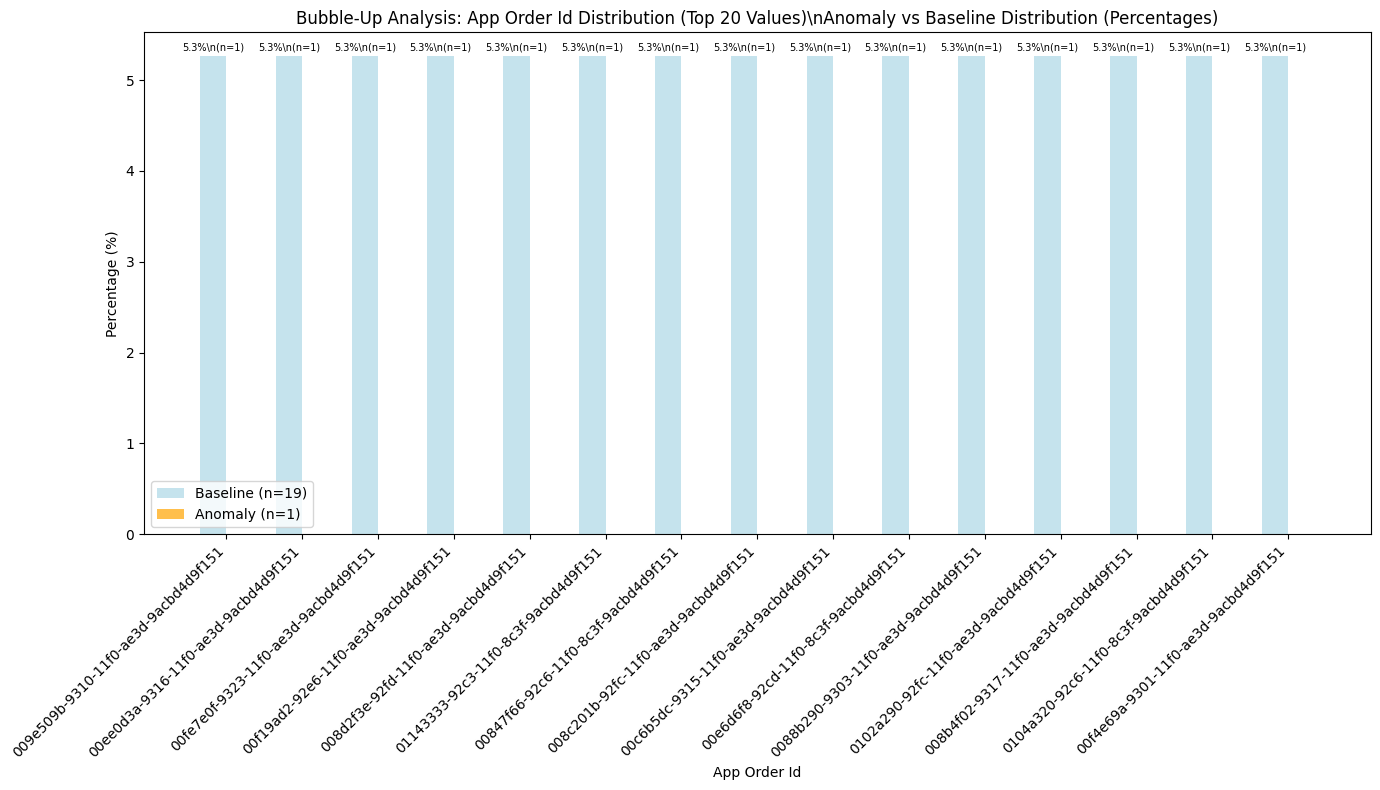

\n🔍 App Order Id Analysis:
   📊 Total anomaly instances: 1
   📊 Total baseline instances: 19
   🟢 Values over-represented in baseline group:
      • 009e509b-9310-11f0-ae3d-9acbd4d9f151: 5.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 00ee0d3a-9316-11f0-ae3d-9acbd4d9f151: 5.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)
      • 00fe7e0f-9323-11f0-ae3d-9acbd4d9f151: 5.3% of baseline vs 0.0% of anomalies (100.0% of this value is baseline)

📋 13. APP CART TOTAL ANALYSIS
   📊 Found 822 unique values for App Cart Total. Showing top 20 by frequency.
   🔝 Using top 20 values (representing 1,779 total instances)


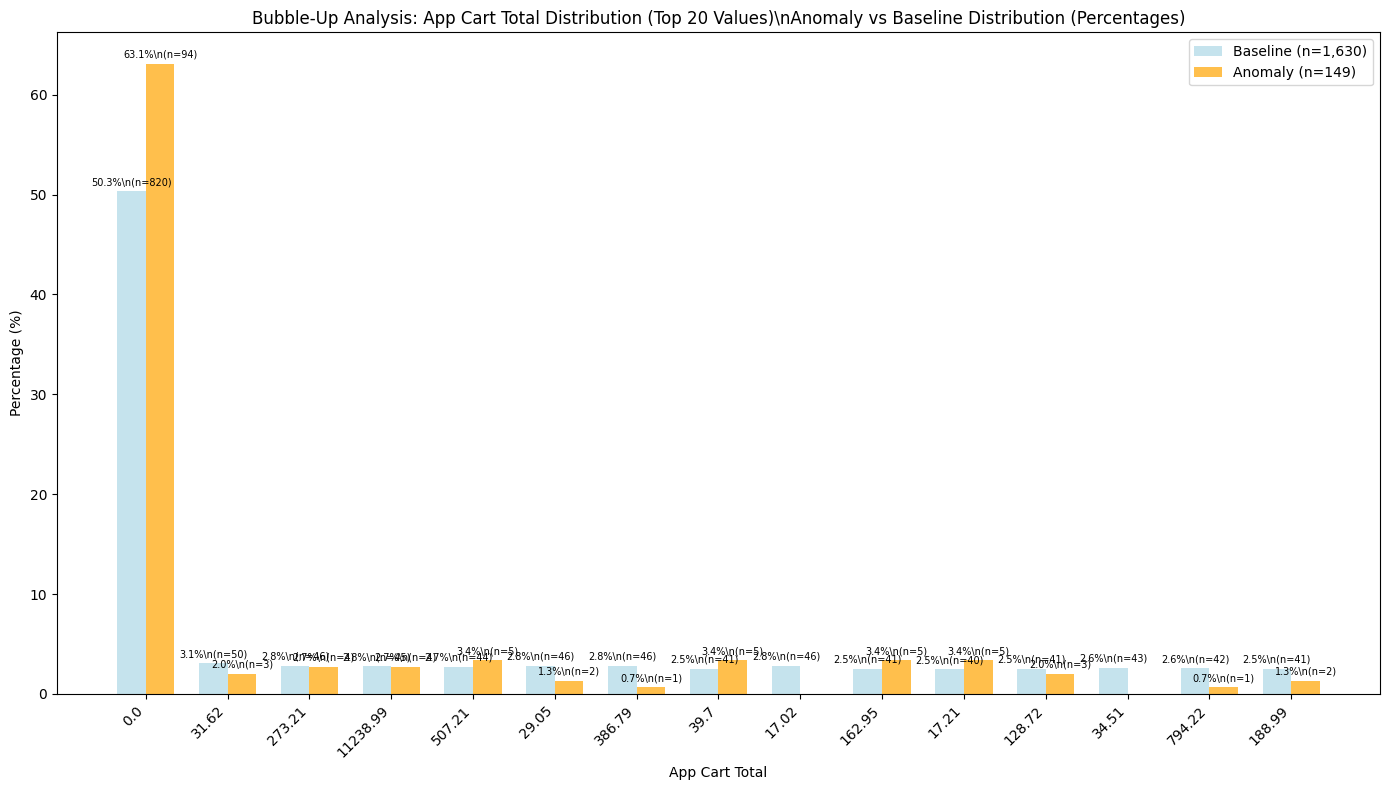

\n🔍 App Cart Total Analysis:
   📊 Total anomaly instances: 149
   📊 Total baseline instances: 1,630
   🟢 Values over-represented in baseline group:
      • 31.62: 3.1% of baseline vs 2.0% of anomalies (94.3% of this value is baseline)
      • 273.21: 2.8% of baseline vs 2.7% of anomalies (92.0% of this value is baseline)
      • 29.05: 2.8% of baseline vs 1.3% of anomalies (95.8% of this value is baseline)

✅ Attribute analysis completed!
   📊 Created 13 attribute comparison charts


In [173]:
# Create paired histograms for attribute columns
import pandas as pd

print("📊 CREATING ATTRIBUTE PAIRED HISTOGRAMS")
print("=" * 50)

if 'actual_attr_columns' in locals() and len(actual_attr_columns) > 0:
    print(f"🎨 Creating paired histograms for {len(actual_attr_columns)} attributes...")
    print(f"📊 Data available: {len(df_anomaly)} anomaly traces, {len(df_baseline)} baseline traces")
    
    figures_created = 0
    MAX_CHARTS = 20  # Limit total charts to prevent overwhelming output
    
    for i, attr_col in enumerate(actual_attr_columns):
        if figures_created >= MAX_CHARTS:
            print(f"\n⚠️ Reached maximum chart limit ({MAX_CHARTS}). Stopping to prevent overwhelming output.")
            break
            
        attr_display_name = attr_col.replace('attr_', '').replace('_', ' ').title()
        
        print(f"\n📋 {i+1}. {attr_display_name.upper()} ANALYSIS")
        
        try:
            # Get the data for both groups, handling potential duplicate columns
            anomaly_data = df_anomaly[attr_col]
            baseline_data = df_baseline[attr_col]
            
            # If we get DataFrames due to duplicate columns, take the first column
            if isinstance(anomaly_data, pd.DataFrame):
                anomaly_data = anomaly_data.iloc[:, 0]
            if isinstance(baseline_data, pd.DataFrame):
                baseline_data = baseline_data.iloc[:, 0]
            
            # Get non-null values for both groups
            anomaly_values = anomaly_data.dropna()
            baseline_values = baseline_data.dropna()
            
            if len(anomaly_values) == 0 and len(baseline_values) == 0:
                print(f"   ⚠️ No data available for {attr_display_name}")
                continue
                
            if len(anomaly_values) == 0:
                print(f"   ⚠️ No anomaly data for {attr_display_name}")
                continue
                
            if len(baseline_values) == 0:
                print(f"   ⚠️ No baseline data for {attr_display_name}")
                continue
            
            # Calculate value counts for both groups
            anomaly_counts = anomaly_values.value_counts()
            baseline_counts = baseline_values.value_counts()
            
            # Get all unique values
            all_values = sorted(set(anomaly_counts.index) | set(baseline_counts.index))
            
            # If too many unique values, select top 20 by total frequency
            if len(all_values) > 20:
                print(f"   📊 Found {len(all_values)} unique values for {attr_display_name}. Showing top 20 by frequency.")
                
                # Calculate total counts for each value (anomaly + baseline)
                total_counts = {}
                for value in all_values:
                    anomaly_count = anomaly_counts.get(value, 0)
                    baseline_count = baseline_counts.get(value, 0)
                    total_counts[value] = anomaly_count + baseline_count
                
                # Sort by total count and take top 20
                top_values = sorted(total_counts.keys(), key=lambda x: total_counts[x], reverse=True)[:20]
                
                # Filter the data to only include top values
                anomaly_values_filtered = anomaly_values[anomaly_values.isin(top_values)]
                baseline_values_filtered = baseline_values[baseline_values.isin(top_values)]
                
                print(f"   🔝 Using top 20 values (representing {len(anomaly_values_filtered) + len(baseline_values_filtered):,} total instances)")
                
                # Use filtered data for visualization
                create_bubbleup_histogram(
                    attr_display_name,
                    anomaly_values_filtered.tolist(),
                    baseline_values_filtered.tolist(),
                    f"{attr_display_name} Distribution (Top 20 Values)"
                )
            else:
                # Use all values if 20 or fewer
                create_bubbleup_histogram(
                    attr_display_name,
                    anomaly_values.tolist(),
                    baseline_values.tolist(),
                    f"{attr_display_name} Distribution"
                )
            
            figures_created += 1
            
        except Exception as e:
            print(f"   ❌ Error creating chart for {attr_display_name}: {e}")
            continue
    
    print(f"\n✅ Attribute analysis completed!")
    print(f"   📊 Created {figures_created} attribute comparison charts")
    
else:
    print("⚠️ No suitable attribute columns found for analysis")
    print("   🔄 Please run the attribute analysis cell first to identify available attributes")

In [174]:
# Enhanced ranking algorithm that focuses on SPECIFIC ATTRIBUTE VALUES
# Prioritizes attribute values where high percentage of spans with that value are high duration spans

def rank_attribute_values_by_high_duration_association(high_group, baseline_group):
    """
    Rank specific attribute VALUES by how strongly they're associated with high duration spans.
    For each attribute value, calculate what percentage of spans with that value are high duration spans.
    Returns a list of tuples: (attribute_value_name, association_strength, metadata)
    """
    value_rankings = []
    
    # Get all columns that could be meaningful attributes
    # Exclude system columns that aren't useful for analysis
    exclude_columns = {
        'TimeGenerated', 'DurationMs', 'Success', 'TraceId', 'SpanId', 
        'ParentId', 'ResourceId', '_ResourceId', 'Type', 'TenantId',
        'SourceSystem', 'MG', 'ManagementGroupName', 'Computer',
        'Timestamp', '_ItemId', '_BilledSize', 'IngestionTime',
        'time_bin', 'duration_bin'  # Also exclude binning columns
    }
    
    all_columns = set(high_group.columns) | set(baseline_group.columns)
    relevant_columns = [col for col in all_columns if col not in exclude_columns]
    
    print(f"🔍 Analyzing attribute values across {len(relevant_columns)} columns...")
    
    total_high = len(high_group)
    total_baseline = len(baseline_group)
    total_spans = total_high + total_baseline
    
    for col in relevant_columns:
        if col not in high_group.columns or col not in baseline_group.columns:
            continue
            
        # Get all unique values for this column
        high_values = high_group[col].dropna()
        baseline_values = baseline_group[col].dropna()
        
        if len(high_values) == 0 and len(baseline_values) == 0:
            continue
            
        # Combine to get all unique values
        all_unique_values = set(high_values.unique()) | set(baseline_values.unique())
        
        # Skip columns with too many unique values (likely IDs)
        if len(all_unique_values) > 100:
            continue
            
        # Determine column type for better display
        if col.startswith('attr_'):
            attr_name = col.replace('attr_', '').replace('_', '.')
            column_type = "Parsed Attribute"
        else:
            attr_name = col
            column_type = "Standard Column"
        
        # Analyze each unique value
        for value in all_unique_values:
            # Count spans with this value in each group
            high_with_value = (high_values == value).sum()
            baseline_with_value = (baseline_values == value).sum()
            total_with_value = high_with_value + baseline_with_value
            
            # Skip values that appear in very few spans
            if total_with_value < 5:
                continue
                
            # Calculate association strength: what % of spans with this value are high duration?
            association_strength = (high_with_value / total_with_value) * 100 if total_with_value > 0 else 0
            
            # Calculate coverage: what % of all high duration spans have this value?
            high_coverage = (high_with_value / total_high) * 100 if total_high > 0 else 0
            baseline_coverage = (baseline_with_value / total_baseline) * 100 if total_baseline > 0 else 0
            
            # Calculate expected association if there was no correlation
            expected_high_rate = (total_high / total_spans) * 100
            lift = association_strength - expected_high_rate
            
            # Only include values that are meaningfully associated with high duration
            if association_strength > expected_high_rate + 5:  # At least 5% lift
                
                # Create display name
                value_str = str(value)
                if len(value_str) > 30:
                    value_str = value_str[:27] + "..."
                display_name = f"{attr_name} = {value_str}"
                
                metadata = {
                    'column_name': col,
                    'attribute_name': attr_name,
                    'attribute_value': value,
                    'column_type': column_type,
                    'high_with_value': high_with_value,
                    'baseline_with_value': baseline_with_value,
                    'total_with_value': total_with_value,
                    'association_strength': association_strength,
                    'high_coverage': high_coverage,
                    'baseline_coverage': baseline_coverage,
                    'expected_high_rate': expected_high_rate,
                    'lift': lift,
                    'display_name': display_name
                }
                
                value_rankings.append((display_name, association_strength, metadata))
    
    # Sort by association strength (descending)
    value_rankings.sort(key=lambda x: x[1], reverse=True)
    return value_rankings

def calculate_value_importance_score(association_strength, high_coverage, lift, total_with_value):
    """
    Calculate importance score for attribute values based on:
    1. Association strength (what % of spans with this value are high duration)
    2. High coverage (what % of high duration spans have this value)
    3. Lift (how much higher than expected)
    4. Sample size (more reliable with larger samples)
    5. Perfect association bonus (100% association gets significant boost)
    """
    # Normalize association strength (0-100 -> 0-1)
    assoc_factor = association_strength / 100.0
    
    # High coverage factor (0-100 -> 0-1) 
    coverage_factor = min(high_coverage / 100.0, 1.0)
    
    # Lift factor (normalize to 0-1, where 50% lift = 1.0)
    lift_factor = min(max(lift, 0) / 50.0, 1.0)
    
    # Sample size factor (logarithmic scaling)
    import math
    size_factor = min(math.log10(max(total_with_value, 1)) / 3.0, 1.0)  # log10(1000) = 3
    
    # Perfect association bonus: Give significant boost to 100% association
    perfect_association_bonus = 0.0
    if association_strength >= 100.0:
        # 100% association gets a major bonus proportional to coverage and sample size
        perfect_association_bonus = 0.5 * coverage_factor * min(size_factor * 2, 1.0)
    elif association_strength >= 95.0:
        # Near-perfect (95%+) gets smaller bonus
        perfect_association_bonus = 0.2 * coverage_factor * min(size_factor * 2, 1.0)
    
    # Combine factors with weights (reduced other weights to accommodate bonus)
    base_score = (assoc_factor * 0.35) + (coverage_factor * 0.25) + (lift_factor * 0.15) + (size_factor * 0.1)
    
    # Add perfect association bonus (can push score above 1.0 for 100% association)
    score = base_score + perfect_association_bonus
    
    return score

# Apply the enhanced ranking to analyze specific attribute values
print("🚀 ENHANCED RANKING: ATTRIBUTE VALUES BY HIGH DURATION ASSOCIATION")
print("=" * 65)

if 'comparison_groups' in globals():
    high_group = comparison_groups['high_duration']
    baseline_group = comparison_groups['baseline']
    
    # Get rankings for all attribute values
    value_rankings = rank_attribute_values_by_high_duration_association(high_group, baseline_group)
    
    # Calculate importance scores and re-rank
    enhanced_rankings = []
    for display_name, association_strength, metadata in value_rankings:
        score = calculate_value_importance_score(
            metadata['association_strength'], 
            metadata['high_coverage'], 
            metadata['lift'],
            metadata['total_with_value']
        )
        metadata['importance_score'] = score
        enhanced_rankings.append((display_name, score, metadata))
    
    # Sort by importance score (descending)
    enhanced_rankings.sort(key=lambda x: x[1], reverse=True)
    
    # Store the rankings for use in graph generation
    ranked_attributes = enhanced_rankings
    
    print(f"✅ Ranked {len(enhanced_rankings)} attribute values by high duration association")
    print(f"\n🏆 TOP 20 ATTRIBUTE VALUES BY HIGH DURATION ASSOCIATION:")
    print("-" * 100)
    print(f"{'Rank':<4} {'Attribute = Value':<45} {'Type':<10} {'Assoc%':<6} {'Cover%':<6} {'Lift':<6} {'Count':<6} {'Score':<6}")
    print("-" * 100)
    
    for i, (display_name, score, metadata) in enumerate(enhanced_rankings[:20], 1):
        col_type = "Attr" if metadata['column_type'] == "Parsed Attribute" else "Col"
        assoc = metadata['association_strength']
        cover = metadata['high_coverage']
        lift = metadata['lift']
        count = metadata['total_with_value']
        
        # Truncate long display names
        short_name = display_name[:44] + "..." if len(display_name) > 47 else display_name
        
        print(f"{i:<4} {short_name:<45} {col_type:<10} "
              f"{assoc:<6.1f} {cover:<6.1f} {lift:<+6.1f} {count:<6} {score:<6.3f}")
    
    # Show breakdown by column type
    attr_count = sum(1 for _, _, meta in enhanced_rankings if meta['column_type'] == "Parsed Attribute")
    std_count = len(enhanced_rankings) - attr_count
    
    print(f"\n📊 ATTRIBUTE VALUE BREAKDOWN:")
    print(f"   📋 Standard Column Values: {std_count}")
    print(f"   🏷️  Parsed Attribute Values: {attr_count}")
    print(f"   📈 Total Analyzed: {len(enhanced_rankings)}")
    
    # Show some insights
    if len(enhanced_rankings) > 0:
        top_item = enhanced_rankings[0]
        top_meta = top_item[2]
        print(f"\n🥇 STRONGEST ASSOCIATION:")
        print(f"   {top_item[0]}")
        print(f"   📊 {top_meta['association_strength']:.1f}% of spans with this value are high duration")
        print(f"   📈 {top_meta['high_coverage']:.1f}% of all high duration spans have this value")
        print(f"   🚀 {top_meta['lift']:+.1f}% lift over expected rate")
        print(f"   🔢 {top_meta['total_with_value']} total spans with this value")
    
    # Show expected vs actual rates
    total_high = len(high_group)
    total_spans = len(high_group) + len(baseline_group)
    expected_rate = (total_high / total_spans) * 100
    print(f"\n📏 BASELINE METRICS:")
    print(f"   Expected high duration rate: {expected_rate:.1f}%")
    print(f"   High duration spans: {total_high:,}")
    print(f"   Total spans: {total_spans:,}")

else:
    print("❌ Missing comparison_groups. Please run the comparison setup cell first.")

🚀 ENHANCED RANKING: ATTRIBUTE VALUES BY HIGH DURATION ASSOCIATION
🔍 Analyzing attribute values across 59 columns...


✅ Ranked 10 attribute values by high duration association

🏆 TOP 20 ATTRIBUTE VALUES BY HIGH DURATION ASSOCIATION:
----------------------------------------------------------------------------------------------------
Rank Attribute = Value                             Type       Assoc% Cover% Lift   Count  Score 
----------------------------------------------------------------------------------------------------
1    Name = /cart/checkout                         Col        57.0   56.0   +52.0  4932   0.589 
2    http.route = /cart/checkout                   Attr       57.0   56.0   +52.0  4932   0.589 
3    net.sock.peer.addr = 10.0.147.123             Attr       53.0   10.1   +48.0  957    0.454 
4    http.method = POST                            Attr       17.9   56.1   +12.9  15740  0.341 
5    Name = msdemo.CheckoutService/Plac...         Col        25.5   30.0   +20.5  5894   0.326 
6    rpc.method = PlaceOrder                       Attr       25.5   30.0   +20.5  5894   0.326 
7   

📊 GENERATING GRAPHS FOR TOP COLUMNS RANKED BY HIGH DURATION PERCENTAGE
✅ All required variables are available
📊 Total ranked columns/attributes: 10

📈 AVAILABLE FOR ANALYSIS:
   📋 Standard Column Values: 2
   🏷️  Parsed Attribute Values: 8
   📊 Total: 10

💡 Generating charts for TOP 8 attribute values only...

📋 1. Name = /cart/checkout
   Type: Standard Column
   🔴 Association: 57.0% of spans with this value are high duration
   📊 Coverage: 56.0% of high duration spans have this value
   🚀 Lift: +52.0% over expected rate
   🔢 Sample size: 4932 spans
   🎯 Score: 0.589


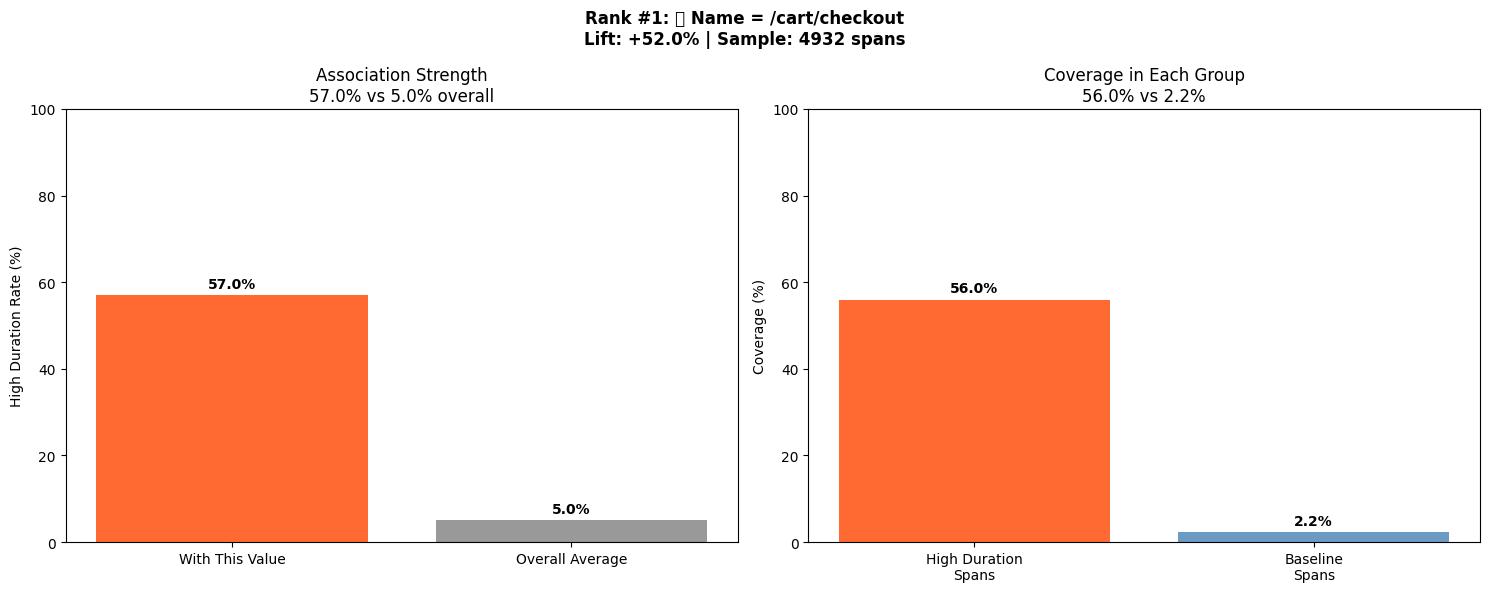

   ✅ Chart created successfully

📋 2. http.route = /cart/checkout
   Type: Parsed Attribute
   🔴 Association: 57.0% of spans with this value are high duration
   📊 Coverage: 56.0% of high duration spans have this value
   🚀 Lift: +52.0% over expected rate
   🔢 Sample size: 4932 spans
   🎯 Score: 0.589


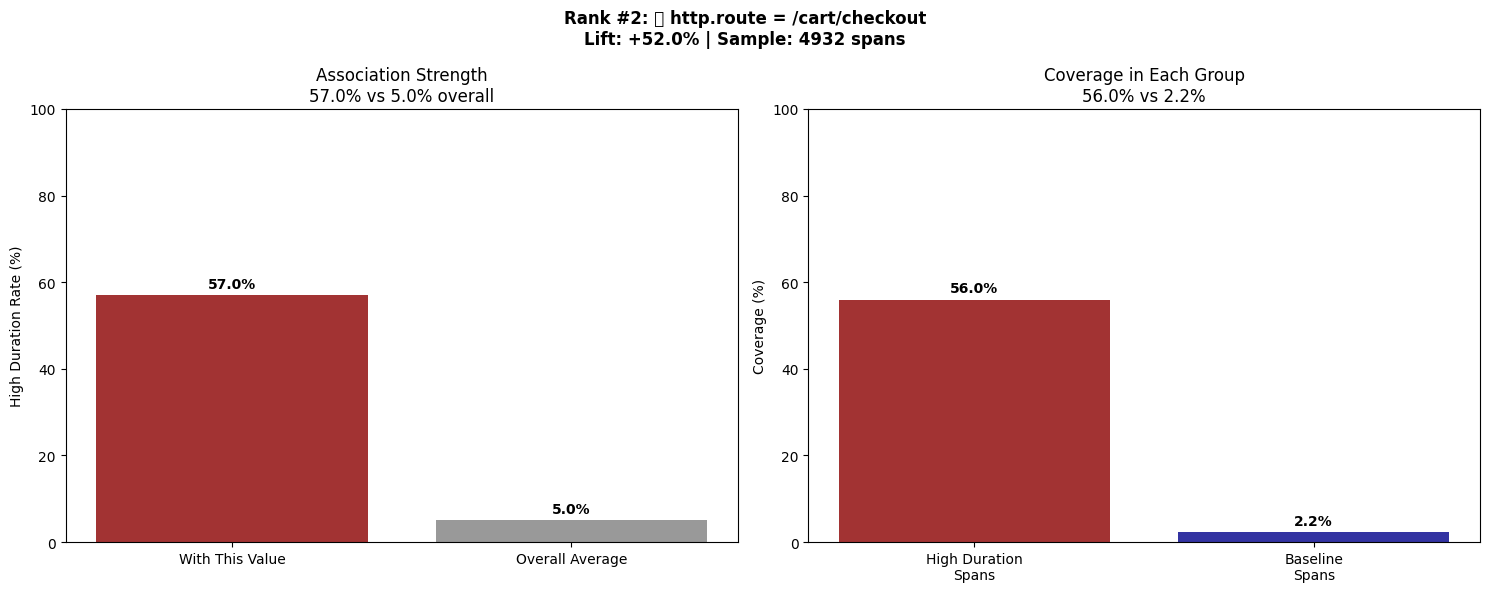

   ✅ Chart created successfully

📋 3. net.sock.peer.addr = 10.0.147.123
   Type: Parsed Attribute
   🔴 Association: 53.0% of spans with this value are high duration
   📊 Coverage: 10.1% of high duration spans have this value
   🚀 Lift: +48.0% over expected rate
   🔢 Sample size: 957 spans
   🎯 Score: 0.454


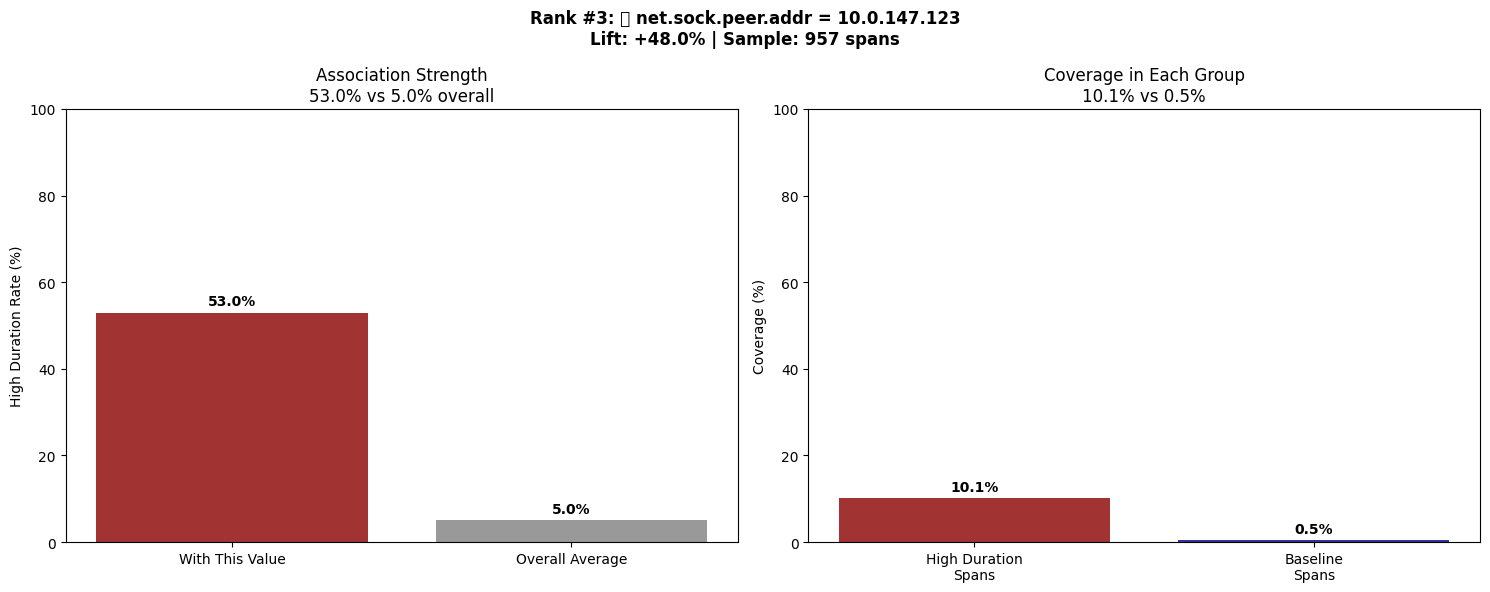

   ✅ Chart created successfully

📋 4. http.method = POST
   Type: Parsed Attribute
   🔴 Association: 17.9% of spans with this value are high duration
   📊 Coverage: 56.1% of high duration spans have this value
   🚀 Lift: +12.9% over expected rate
   🔢 Sample size: 15740 spans
   🎯 Score: 0.341


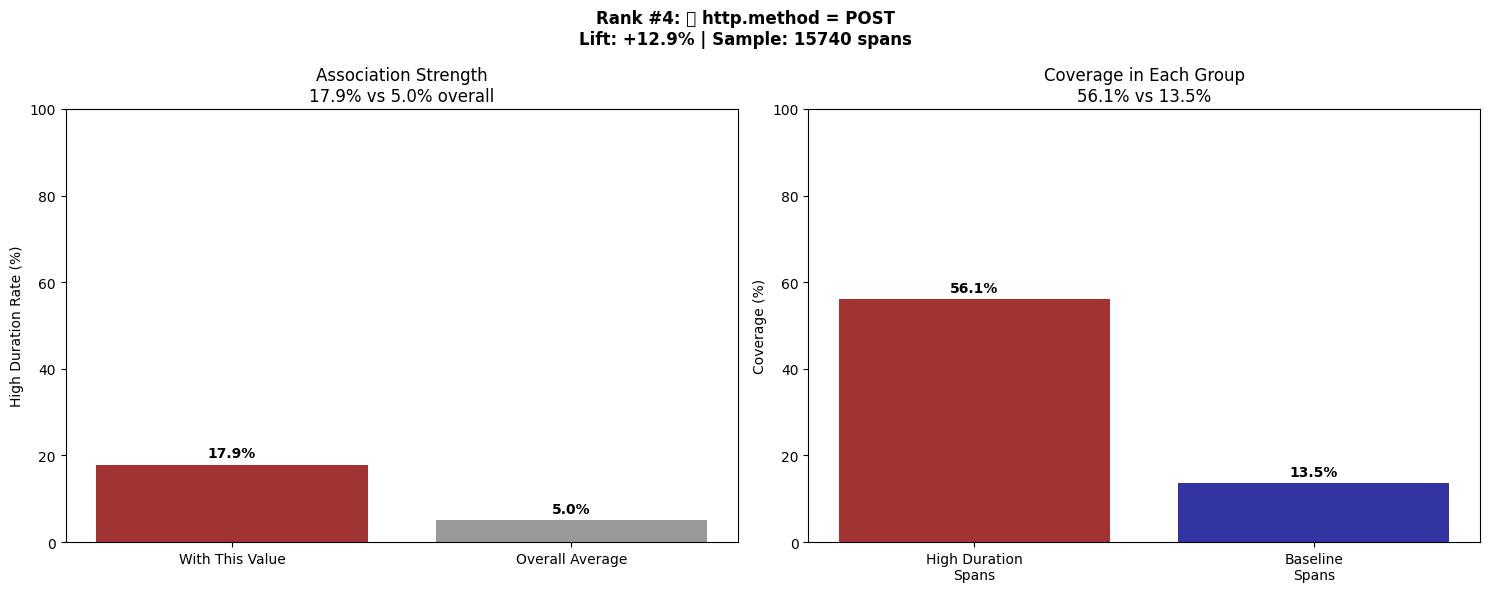

   ✅ Chart created successfully

📋 5. Name = msdemo.CheckoutService/Plac...
   Type: Standard Column
   🔴 Association: 25.5% of spans with this value are high duration
   📊 Coverage: 30.0% of high duration spans have this value
   🚀 Lift: +20.5% over expected rate
   🔢 Sample size: 5894 spans
   🎯 Score: 0.326


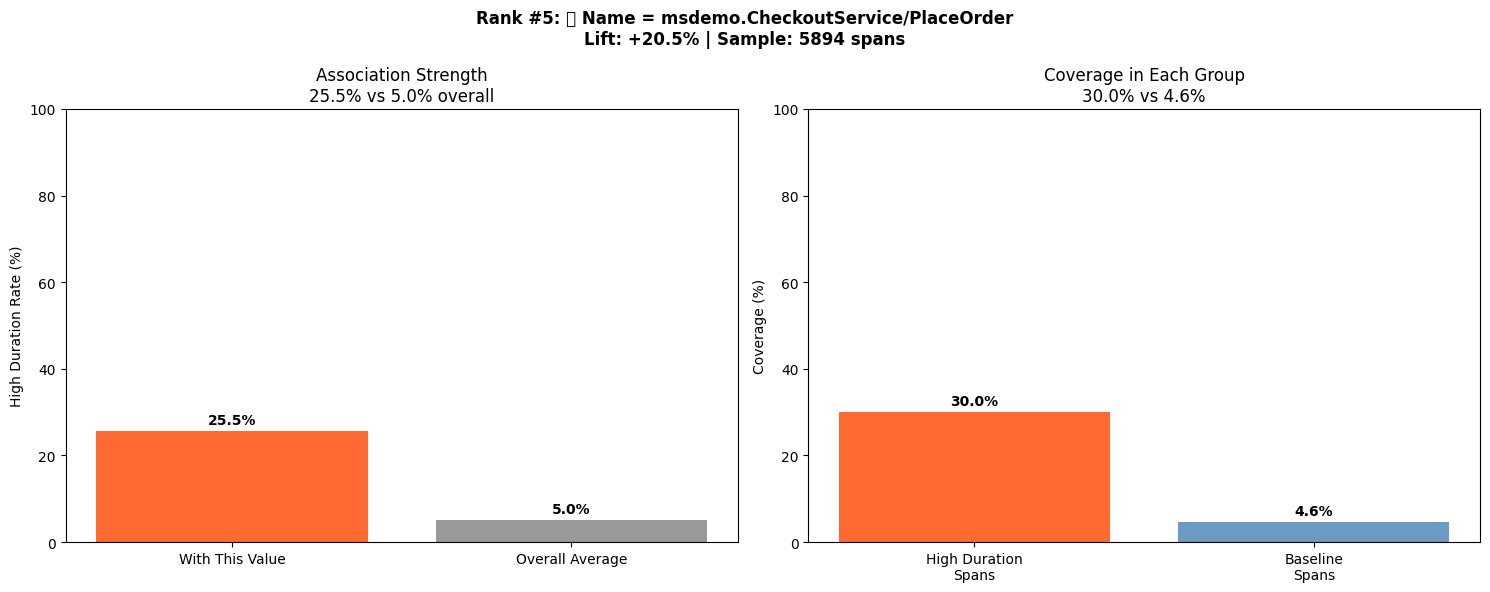

   ✅ Chart created successfully

📋 6. rpc.method = PlaceOrder
   Type: Parsed Attribute
   🔴 Association: 25.5% of spans with this value are high duration
   📊 Coverage: 30.0% of high duration spans have this value
   🚀 Lift: +20.5% over expected rate
   🔢 Sample size: 5894 spans
   🎯 Score: 0.326


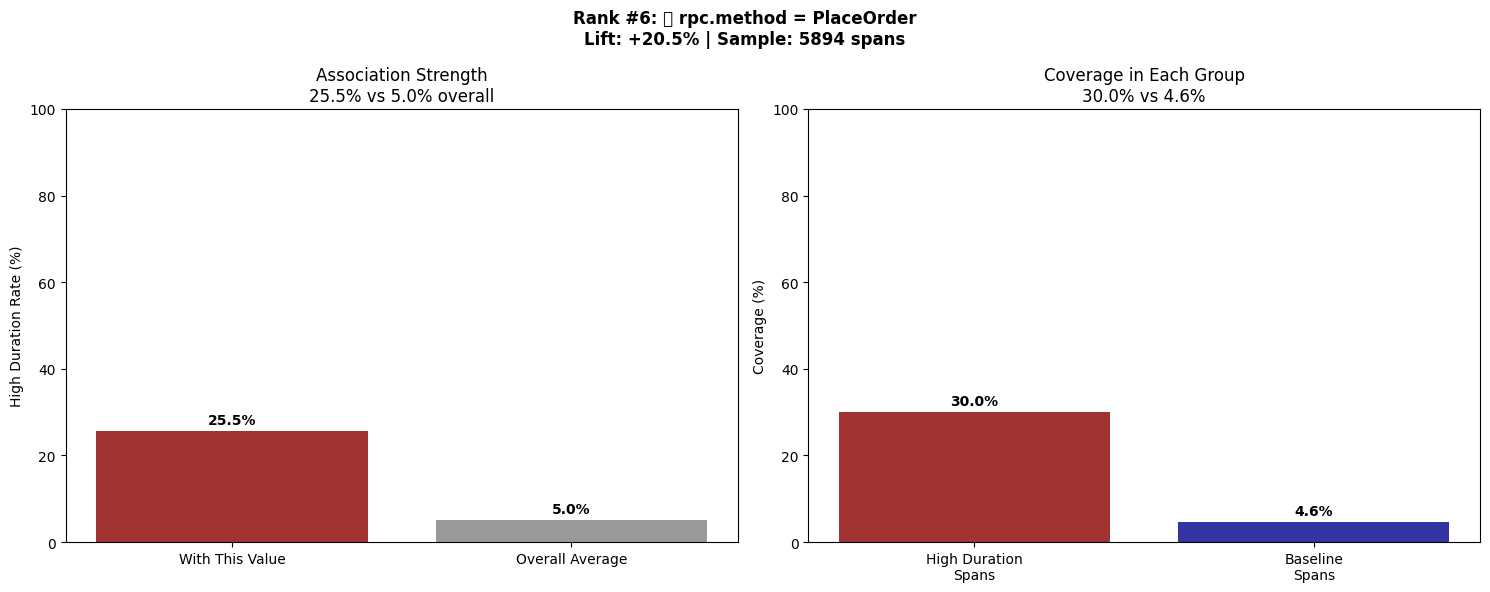

   ✅ Chart created successfully

📋 7. rpc.service = msdemo.CheckoutService
   Type: Parsed Attribute
   🔴 Association: 23.6% of spans with this value are high duration
   📊 Coverage: 30.0% of high duration spans have this value
   🚀 Lift: +18.6% over expected rate
   🔢 Sample size: 6379 spans
   🎯 Score: 0.313


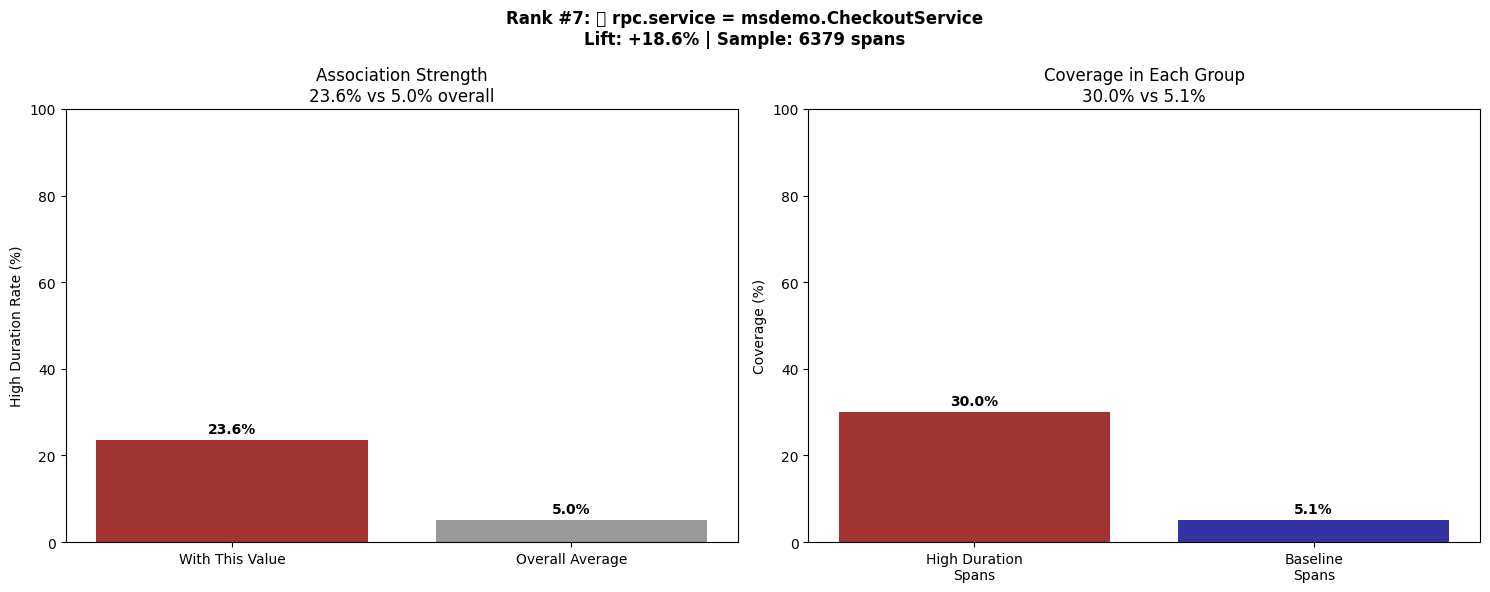

   ✅ Chart created successfully

📋 8. num.products = 5
   Type: Parsed Attribute
   🔴 Association: 10.7% of spans with this value are high duration
   📊 Coverage: 56.0% of high duration spans have this value
   🚀 Lift: +5.7% over expected rate
   🔢 Sample size: 26348 spans
   🎯 Score: 0.294


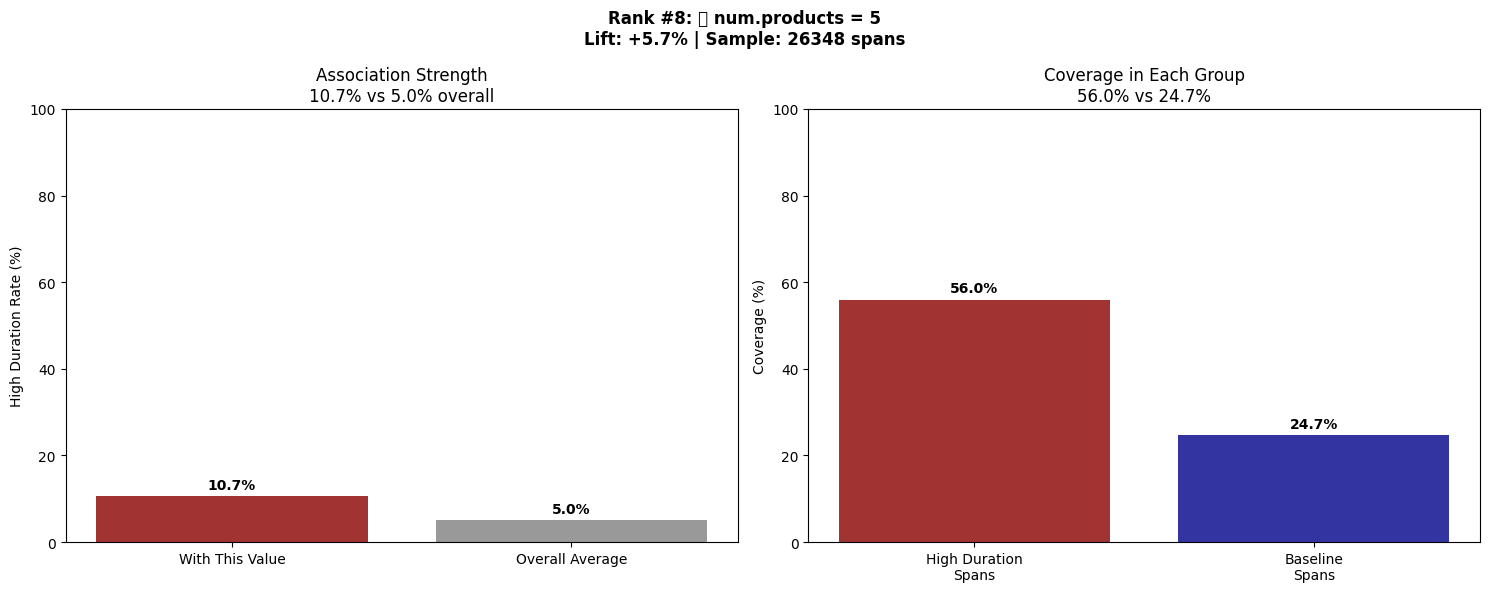

   ✅ Chart created successfully

✅ TOP ATTRIBUTE VALUES ANALYSIS COMPLETE
   📊 Total attribute values available: 10
   📈 Charts created: 8
   ⚠️ Charts skipped: 0
   🎯 Showing top 8 by association strength
   💡 Limited to 8 charts to avoid performance issues

🔍 REMAINING HIGH-VALUE ATTRIBUTE VALUES (not charted):
   9. app.build.id = bdebb71c
      11.1% association, 49.7% coverage, +6.1% lift
   10. rpc.grpc.status.code = 13
      11.5% association, 8.1% coverage, +6.5% lift


In [175]:
# Generate comparison graphs for TOP columns ranked by high duration percentage (OPTIMIZED)
print("📊 GENERATING GRAPHS FOR TOP COLUMNS RANKED BY HIGH DURATION PERCENTAGE")
print("=" * 70)

# Check if required variables exist
if 'comparison_groups' not in globals():
    print("❌ Cannot proceed without comparison_groups")
elif 'ranked_attributes' not in globals():
    print("❌ Cannot proceed without ranked_attributes. Please run the ranking cell first.")
else:
    import matplotlib.pyplot as plt
    import seaborn as sns
    from collections import Counter
    import numpy as np

    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    print("✅ All required variables are available")
    print(f"📊 Total ranked columns/attributes: {len(ranked_attributes)}")

    def create_attribute_value_chart(value_info):
        """
        Create a chart showing the association between a specific attribute value and high duration spans
        """
        display_name = value_info[0]
        metadata = value_info[2]
        column_name = metadata['column_name']
        attribute_value = metadata['attribute_value']
        column_type = metadata['column_type']
        
        # Get high duration and baseline groups
        high_group = comparison_groups['high_duration']
        baseline_group = comparison_groups['baseline']
        
        # Count spans with and without this specific value
        high_with_value = (high_group[column_name] == attribute_value).sum()
        high_without_value = len(high_group) - high_with_value
        baseline_with_value = (baseline_group[column_name] == attribute_value).sum()
        baseline_without_value = len(baseline_group) - baseline_with_value
        
        if high_with_value == 0 and baseline_with_value == 0:
            return None
            
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Chart 1: Association strength (what % of spans with this value are high duration)
        total_with_value = high_with_value + baseline_with_value
        if total_with_value > 0:
            high_rate_with_value = (high_with_value / total_with_value) * 100
        else:
            high_rate_with_value = 0
            
        # Compare to overall high duration rate
        total_spans = len(high_group) + len(baseline_group)
        overall_high_rate = (len(high_group) / total_spans) * 100
        
        # Create comparison bars
        categories = ['With This Value', 'Overall Average']
        rates = [high_rate_with_value, overall_high_rate]
        colors = ['darkred' if column_type == "Parsed Attribute" else 'orangered', 'gray']
        
        bars1 = ax1.bar(categories, rates, color=colors, alpha=0.8)
        ax1.set_ylabel('High Duration Rate (%)')
        ax1.set_title(f'Association Strength\n{high_rate_with_value:.1f}% vs {overall_high_rate:.1f}% overall')
        ax1.set_ylim(0, max(100, max(rates) * 1.1))
        
        # Add value labels on bars
        for bar, rate in zip(bars1, rates):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        # Chart 2: Coverage (how much of each group has this value)
        high_coverage = (high_with_value / len(high_group)) * 100 if len(high_group) > 0 else 0
        baseline_coverage = (baseline_with_value / len(baseline_group)) * 100 if len(baseline_group) > 0 else 0
        
        groups = ['High Duration\nSpans', 'Baseline\nSpans']
        coverages = [high_coverage, baseline_coverage]
        colors2 = ['darkred' if column_type == "Parsed Attribute" else 'orangered', 
                  'darkblue' if column_type == "Parsed Attribute" else 'steelblue']
        
        bars2 = ax2.bar(groups, coverages, color=colors2, alpha=0.8)
        ax2.set_ylabel('Coverage (%)')
        ax2.set_title(f'Coverage in Each Group\n{high_coverage:.1f}% vs {baseline_coverage:.1f}%')
        ax2.set_ylim(0, max(100, max(coverages) * 1.1))
        
        # Add value labels on bars
        for bar, coverage in zip(bars2, coverages):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{coverage:.1f}%', ha='center', va='bottom', fontweight='bold')
        
        # Overall title
        type_indicator = "🏷️" if column_type == "Parsed Attribute" else "📋"
        # Truncate long attribute values for title
        value_str = str(attribute_value)
        if len(value_str) > 50:
            value_str = value_str[:47] + "..."
        
        suptitle = f'{type_indicator} {metadata["attribute_name"]} = {value_str}\n'
        suptitle += f'Lift: {metadata["lift"]:+.1f}% | Sample: {metadata["total_with_value"]} spans'
        fig.suptitle(suptitle, fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        return fig

    # Show summary of what we're analyzing
    attr_count = sum(1 for _, _, meta in ranked_attributes if meta['column_type'] == "Parsed Attribute")
    std_count = len(ranked_attributes) - attr_count
    
    print(f"\n📈 AVAILABLE FOR ANALYSIS:")
    print(f"   📋 Standard Column Values: {std_count}")
    print(f"   🏷️  Parsed Attribute Values: {attr_count}")
    print(f"   📊 Total: {len(ranked_attributes)}")
    
    # LIMIT to top 8 only to avoid infinite loops
    MAX_CHARTS = 8
    print(f"\n💡 Generating charts for TOP {MAX_CHARTS} attribute values only...")
    print("=" * 70)

    # Generate graphs for top attribute values (LIMITED)
    figures_created = 0
    skipped_count = 0
    
    for i, value_info in enumerate(ranked_attributes[:MAX_CHARTS], 1):
        display_name, score, metadata = value_info
        
        print(f"\n📋 {i}. {display_name}")
        print(f"   Type: {metadata['column_type']}")
        print(f"   🔴 Association: {metadata['association_strength']:.1f}% of spans with this value are high duration")
        print(f"   📊 Coverage: {metadata['high_coverage']:.1f}% of high duration spans have this value")
        print(f"   🚀 Lift: {metadata['lift']:+.1f}% over expected rate")
        print(f"   🔢 Sample size: {metadata['total_with_value']} spans")
        print(f"   🎯 Score: {metadata['importance_score']:.3f}")
        
        try:
            fig = create_attribute_value_chart(value_info)
            
            if fig is not None:
                # Add ranking info to title
                current_title = fig._suptitle.get_text() if fig._suptitle else ""
                new_title = f"Rank #{i}: {current_title}"
                fig.suptitle(new_title, fontsize=12, fontweight='bold')
                
                plt.show()
                figures_created += 1
                print(f"   ✅ Chart created successfully")
            else:
                print(f"   ⚠️ Skipped - no useful data to display")
                skipped_count += 1
        except Exception as e:
            print(f"   ❌ Error creating chart: {str(e)[:100]}...")
            skipped_count += 1
            continue

    print(f"\n✅ TOP ATTRIBUTE VALUES ANALYSIS COMPLETE")
    print(f"   📊 Total attribute values available: {len(ranked_attributes)}")
    print(f"   📈 Charts created: {figures_created}")
    print(f"   ⚠️ Charts skipped: {skipped_count}")
    print(f"   🎯 Showing top {MAX_CHARTS} by association strength")
    print(f"   💡 Limited to {MAX_CHARTS} charts to avoid performance issues")
    
    if len(ranked_attributes) > MAX_CHARTS:
        print(f"\n🔍 REMAINING HIGH-VALUE ATTRIBUTE VALUES (not charted):")
        for i, (name, score, meta) in enumerate(ranked_attributes[MAX_CHARTS:MAX_CHARTS+10], MAX_CHARTS+1):
            short_name = name[:50] + "..." if len(name) > 53 else name
            print(f"   {i}. {short_name}")
            print(f"      {meta['association_strength']:.1f}% association, {meta['high_coverage']:.1f}% coverage, {meta['lift']:+.1f}% lift")

In [176]:
# Analyze the duration distribution to fix the bucketing issue
print("🔍 ANALYZING DURATION DISTRIBUTION")
print("=" * 50)

if 'df_complete' in locals() and len(df_complete) > 0:
    # Get basic stats
    duration_stats = df_complete['DurationMs'].describe()
    print(f"📊 Duration Statistics:")
    print(f"   Count: {duration_stats['count']:,.0f}")
    print(f"   Min: {duration_stats['min']:,.0f} ms")
    print(f"   25th percentile: {duration_stats['25%']:,.0f} ms")
    print(f"   Median: {duration_stats['50%']:,.0f} ms")
    print(f"   75th percentile: {duration_stats['75%']:,.0f} ms")
    print(f"   95th percentile: {df_complete['DurationMs'].quantile(0.95):,.0f} ms")
    print(f"   99th percentile: {df_complete['DurationMs'].quantile(0.99):,.0f} ms")
    print(f"   Max: {duration_stats['max']:,.0f} ms")
    
    # Check distribution
    print(f"\n📈 Distribution Analysis:")
    total_count = len(df_complete)
    
    # Count data in different ranges
    under_1s = len(df_complete[df_complete['DurationMs'] < 1000])
    under_10s = len(df_complete[df_complete['DurationMs'] < 10000])
    under_1m = len(df_complete[df_complete['DurationMs'] < 60000])
    under_10m = len(df_complete[df_complete['DurationMs'] < 600000])
    
    print(f"   < 1 second (1,000ms): {under_1s:,} spans ({under_1s/total_count*100:.1f}%)")
    print(f"   < 10 seconds (10,000ms): {under_10s:,} spans ({under_10s/total_count*100:.1f}%)")
    print(f"   < 1 minute (60,000ms): {under_1m:,} spans ({under_1m/total_count*100:.1f}%)")
    print(f"   < 10 minutes (600,000ms): {under_10m:,} spans ({under_10m/total_count*100:.1f}%)")
    
    # Show the problem with current linear buckets
    print(f"\n⚠️ Current Linear Bucket Analysis:")
    print(f"   Bucket size: {bucket_size:,.0f} ms")
    print(f"   Most data is clustered in the first few buckets!")
    print(f"   This is why the heatmap looks empty - need logarithmic or percentile buckets")
    
else:
    print("❌ No df_complete data available. Run the heatmap cell first.")

🔍 ANALYZING DURATION DISTRIBUTION
📊 Duration Statistics:
   Count: 76,118
   Min: 4 ms
   25th percentile: 25,929 ms
   Median: 80,764 ms
   75th percentile: 227,969 ms
   95th percentile: 687,850 ms
   99th percentile: 972,402 ms
   Max: 961,540,216 ms

📈 Distribution Analysis:
   < 1 second (1,000ms): 5,940 spans (7.8%)
   < 10 seconds (10,000ms): 5,971 spans (7.8%)
   < 1 minute (60,000ms): 32,315 spans (42.5%)
   < 10 minutes (600,000ms): 69,493 spans (91.3%)

⚠️ Current Linear Bucket Analysis:
   Bucket size: 38,461,608 ms
   Most data is clustered in the first few buckets!
   This is why the heatmap looks empty - need logarithmic or percentile buckets
